In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
pythonafroz_solar_panel_images_path = kagglehub.dataset_download('pythonafroz/solar-panel-images')

print('Data source import complete.')


Using Colab cache for faster access to the 'solar-panel-images' dataset.
Data source import complete.


In [2]:
# ==============================================================================
# IMPROVED CNN-BASED SOLAR PANEL FAULT DETECTION WITH VISUALIZATIONS
# Target: 80%+ Accuracy with comprehensive visual analysis
# ==============================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0, InceptionV3
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# --- HYPERPARAMETERS ---
DATA_DIR = '/kaggle/input/solar-panel-images'
IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 16
RANDOM_SEED = 42
EPOCHS_STAGE1 = 30  # Adjustable
EPOCHS_STAGE2 = 50  # Adjustable
INITIAL_LR = 0.001
FINETUNE_LR = 0.0001

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


In [3]:
# ==============================================================================
# VISUALIZATION FUNCTIONS
# ==============================================================================

def plot_dataset_distribution(df, title="Dataset Distribution"):
    """Visualize class distribution in the dataset"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Count plot
    class_counts = df['label'].value_counts()
    colors = sns.color_palette("husl", len(class_counts))
    ax1.bar(range(len(class_counts)), class_counts.values, color=colors)
    ax1.set_xticks(range(len(class_counts)))
    ax1.set_xticklabels(class_counts.index, rotation=45, ha='right')
    ax1.set_ylabel('Number of Images', fontsize=12)
    ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # Add count labels on bars
    for i, v in enumerate(class_counts.values):
        ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

    # Pie chart
    ax2.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax2.set_title('Class Percentage Distribution', fontsize=14, fontweight='bold')

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def plot_sample_images(generator, class_names, num_images=12):
    """Display sample images from each class"""
    batch = next(generator)
    images, labels = batch[0], batch[1]

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()

    for i in range(min(num_images, len(images))):
        axes[i].imshow(images[i])
        class_idx = np.argmax(labels[i])
        axes[i].set_title(f'Class: {class_names[class_idx]}', fontsize=12, fontweight='bold')
        axes[i].axis('off')

    plt.suptitle('Sample Training Images with Augmentation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Reset generator
    generator.reset()

def plot_training_history(history, stage_name, model_name):
    """Plot training and validation metrics over epochs"""
    fig = plt.figure(figsize=(16, 5))
    gs = GridSpec(1, 3, figure=fig)

    # Accuracy plot
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o', markersize=4)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s', markersize=4)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.set_title(f'{model_name} - {stage_name}\nAccuracy Progress', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Loss plot
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o', markersize=4)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=4)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.set_title(f'{model_name} - {stage_name}\nLoss Progress', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # Learning rate plot (if available)
    ax3 = fig.add_subplot(gs[0, 2])
    if 'lr' in history.history:
        ax3.plot(history.history['lr'], linewidth=2, marker='o', markersize=4, color='red')
        ax3.set_xlabel('Epoch', fontsize=12)
        ax3.set_ylabel('Learning Rate', fontsize=12)
        ax3.set_title(f'{model_name} - {stage_name}\nLearning Rate Schedule', fontsize=12, fontweight='bold')
        ax3.set_yscale('log')
        ax3.grid(True, alpha=0.3)
    else:
        # Show epoch vs best accuracy if LR not available
        best_val_acc = [max(history.history['val_accuracy'][:i+1]) for i in range(len(history.history['val_accuracy']))]
        ax3.plot(best_val_acc, linewidth=2, marker='o', markersize=4, color='green')
        ax3.set_xlabel('Epoch', fontsize=12)
        ax3.set_ylabel('Best Val Accuracy So Far', fontsize=12)
        ax3.set_title(f'{model_name} - {stage_name}\nBest Validation Accuracy Progress', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """Plot detailed confusion matrix with percentages"""
    cm = confusion_matrix(y_true, y_pred)

    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Absolute numbers
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, ax=ax1, cbar_kws={'label': 'Count'})
    ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax1.set_title(f'{model_name}\nConfusion Matrix (Counts)', fontsize=14, fontweight='bold')

    # Percentages
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens', xticklabels=class_names,
                yticklabels=class_names, ax=ax2, cbar_kws={'label': 'Percentage'})
    ax2.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax2.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax2.set_title(f'{model_name}\nConfusion Matrix (% by Row)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return cm

def plot_per_class_metrics(y_true, y_pred, class_names, model_name):
    """Plot per-class precision, recall, and F1-score"""
    from sklearn.metrics import precision_recall_fscore_support

    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, zero_division=0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    x = np.arange(len(class_names))
    width = 0.25

    # Metrics comparison
    axes[0].bar(x - width, precision, width, label='Precision', alpha=0.8)
    axes[0].bar(x, recall, width, label='Recall', alpha=0.8)
    axes[0].bar(x + width, f1, width, label='F1-Score', alpha=0.8)
    axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{model_name}\nPer-Class Performance Metrics', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].legend()
    axes[0].set_ylim([0, 1.1])
    axes[0].grid(axis='y', alpha=0.3)

    # Support (number of samples per class)
    colors = sns.color_palette("husl", len(class_names))
    axes[1].bar(x, support, color=colors, alpha=0.8)
    axes[1].set_xlabel('Class', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Test Samples', fontsize=12, fontweight='bold')
    axes[1].set_title(f'{model_name}\nTest Set Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(support):
        axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

def plot_model_comparison(results_dict):
    """Compare all models side by side"""
    models = list(results_dict.keys())
    accuracies = [results_dict[m]['accuracy'] for m in models]
    f1_scores = [results_dict[m]['f1_weighted'] for m in models]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    x = np.arange(len(models))
    colors = sns.color_palette("husl", len(models))

    # Accuracy comparison
    bars1 = ax1.bar(x, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.set_ylim([0, 1.1])
    ax1.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='80% Target')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)

    # Add percentage labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height*100:.1f}%', ha='center', va='bottom', fontweight='bold')

    # F1-Score comparison
    bars2 = ax2.bar(x, f1_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Weighted F1-Score', fontsize=12, fontweight='bold')
    ax2.set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(models, rotation=45, ha='right')
    ax2.set_ylim([0, 1.1])
    ax2.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='80% Target')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    # Add percentage labels on bars
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height*100:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()






PHASE 1: DATA PREPARATION WITH VISUALIZATION

✓ Total images found: 885



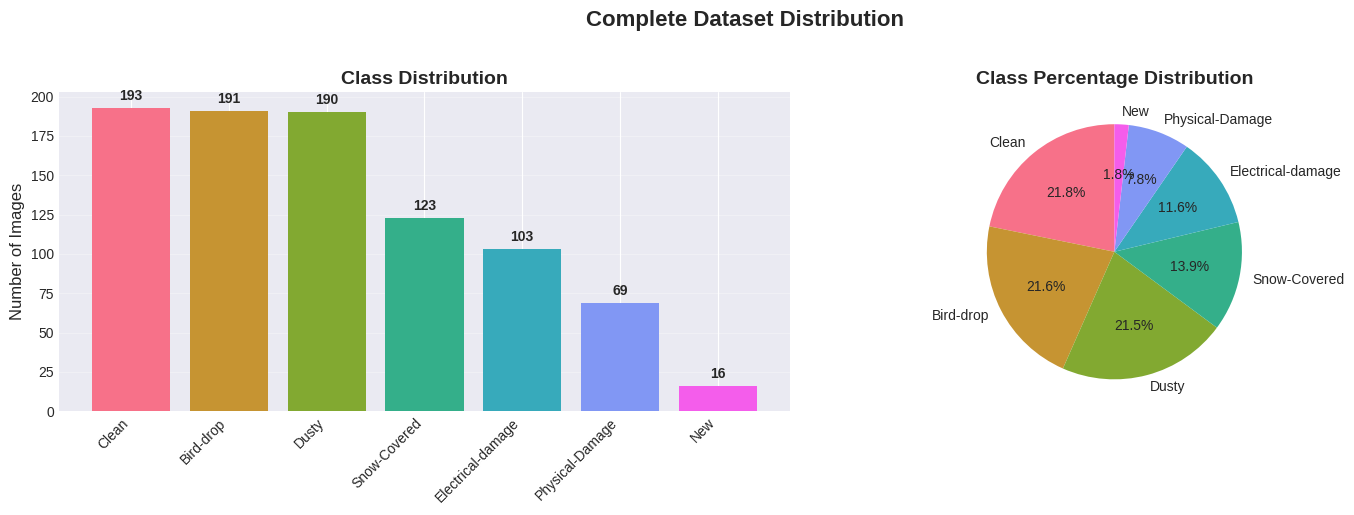

✓ Train: 619 | Val: 133 | Test: 133



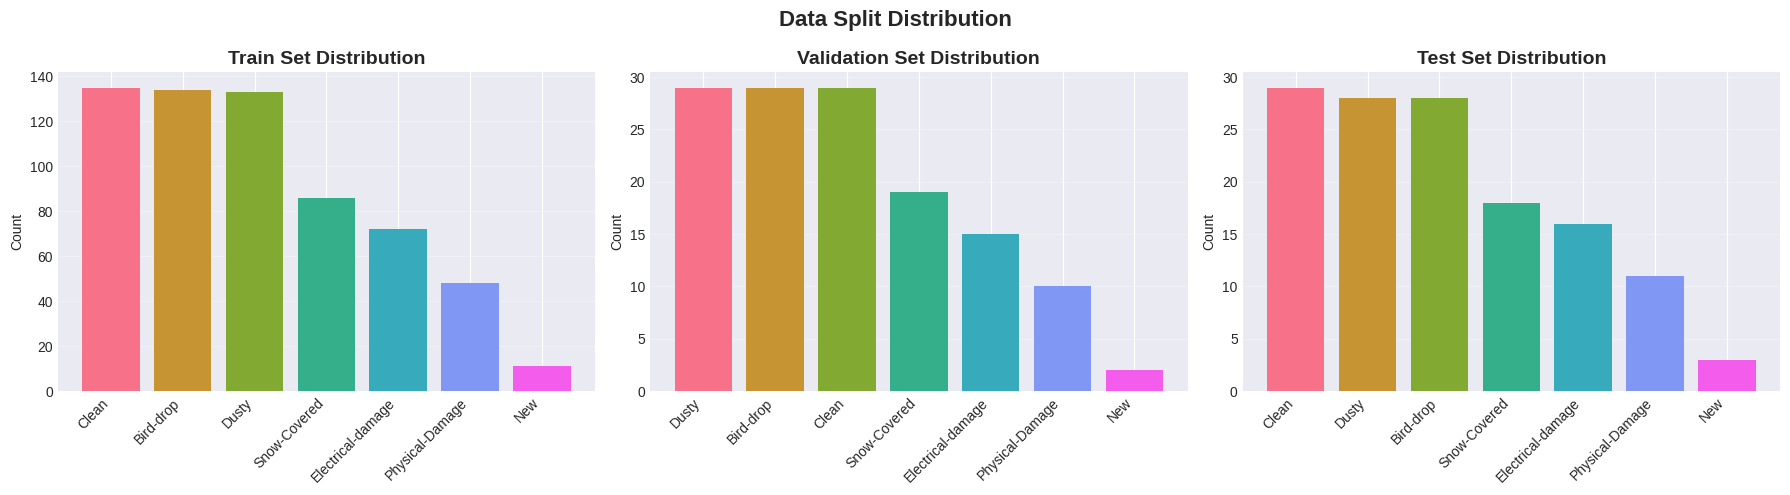

✓ Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'New', 'Physical-Damage', 'Snow-Covered']



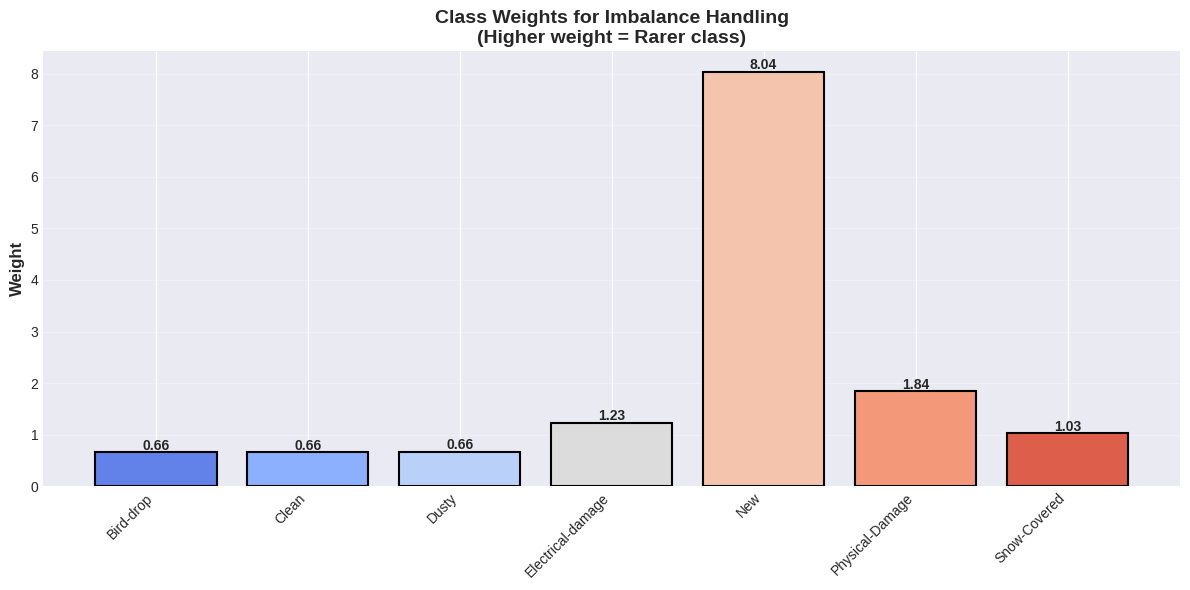

Found 619 validated image filenames belonging to 7 classes.
Found 133 validated image filenames belonging to 7 classes.
Found 133 validated image filenames belonging to 7 classes.

Generating sample augmented images...


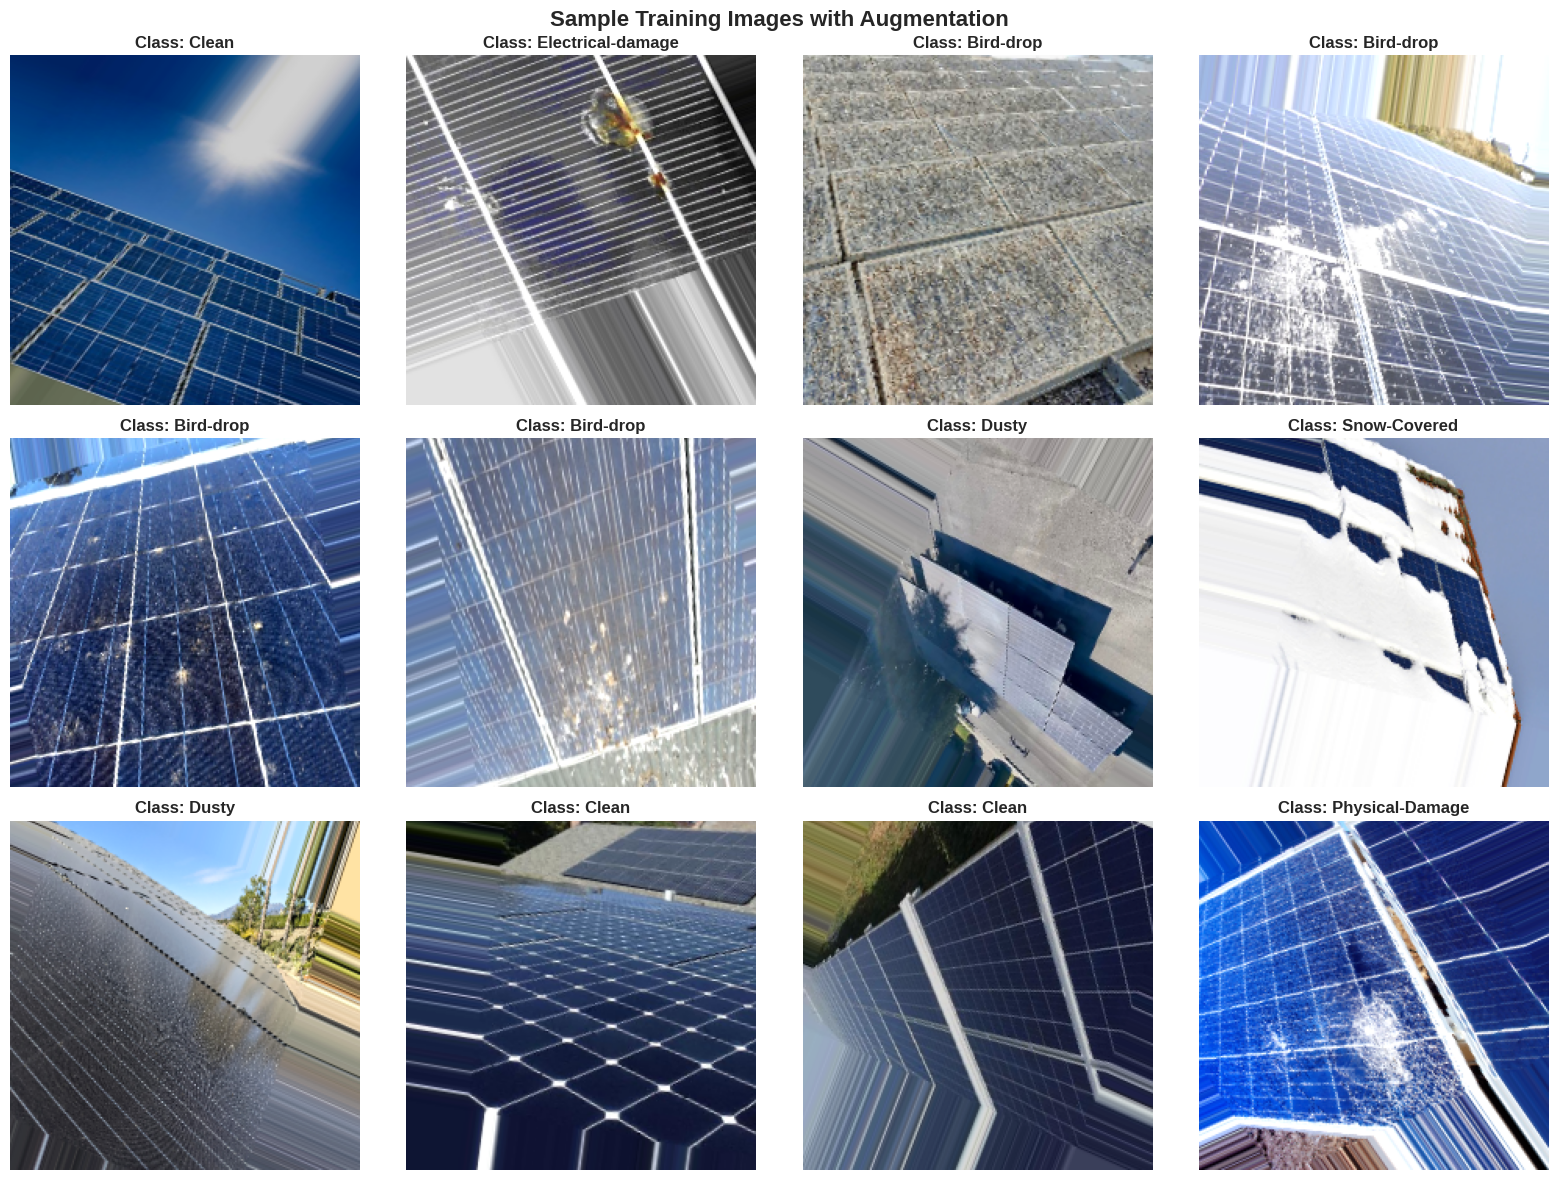

In [4]:
# ==============================================================================
# DATA PREPARATION
# ==============================================================================

print("=" * 70)
print("PHASE 1: DATA PREPARATION WITH VISUALIZATION")
print("=" * 70)

filepaths = []
labels = []

def find_images_recursive(root_path):
    """Recursively find all images"""
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp'}
    for root, dirs, files in os.walk(root_path):
        for file in files:
            if os.path.splitext(file.lower())[1] in image_extensions:
                full_path = os.path.join(root, file)
                label = os.path.basename(os.path.dirname(full_path))
                filepaths.append(full_path)
                labels.append(label)

try:
    find_images_recursive(DATA_DIR)
    if len(filepaths) == 0:
        raise FileNotFoundError("No images found!")
except Exception as e:
    print(f"Error: {e}")
    exit()

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
print(f"\n✓ Total images found: {len(df)}\n")

# VISUALIZATION 1: Dataset Distribution
plot_dataset_distribution(df, "Complete Dataset Distribution")

# Stratified split
df_train, df_temp = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp['label'], random_state=RANDOM_SEED)

print(f"✓ Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}\n")

# VISUALIZATION 2: Split Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (data, title) in enumerate([(df_train, 'Train'), (df_val, 'Validation'), (df_test, 'Test')]):
    counts = data['label'].value_counts()
    axes[idx].bar(range(len(counts)), counts.values, color=sns.color_palette("husl", len(counts)))
    axes[idx].set_xticks(range(len(counts)))
    axes[idx].set_xticklabels(counts.index, rotation=45, ha='right')
    axes[idx].set_title(f'{title} Set Distribution', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(axis='y', alpha=0.3)
plt.suptitle('Data Split Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

sorted_labels = sorted(df['label'].unique())
NUM_CLASSES = len(sorted_labels)
print(f"✓ Classes: {sorted_labels}\n")

# Class weights
y_train = df_train['label'].values
class_weights_array = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights_array)}

# VISUALIZATION 3: Class Weights
fig, ax = plt.subplots(figsize=(12, 6))
weights_list = [class_weight_dict[i] for i in range(NUM_CLASSES)]
colors = sns.color_palette("coolwarm", len(weights_list))
bars = ax.bar(range(len(sorted_labels)), weights_list, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right')
ax.set_ylabel('Weight', fontsize=12, fontweight='bold')
ax.set_title('Class Weights for Imbalance Handling\n(Higher weight = Rarer class)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05, f'{height:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=30, width_shift_range=0.25, height_shift_range=0.25,
    shear_range=0.2, zoom_range=0.25, horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.8, 1.2], fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train, x_col='filepath', y_col='label', target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', classes=sorted_labels, seed=RANDOM_SEED, shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    df_val, x_col='filepath', y_col='label', target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', classes=sorted_labels, seed=RANDOM_SEED, shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    df_test, x_col='filepath', y_col='label', target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE, class_mode='categorical', classes=sorted_labels, shuffle=False
)

# VISUALIZATION 4: Sample augmented images
print("\nGenerating sample augmented images...")
plot_sample_images(train_generator, sorted_labels)

# ==============================================================================
# MODEL TRAINING WITH VISUALIZATIONS
# ==============================================================================

results_dict = {}

def evaluate_and_report(model, generator, model_name, class_names):
    """Comprehensive evaluation with visualizations"""
    generator.reset()

    predictions = model.predict(generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    loss, acc = model.evaluate(generator, verbose=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    f1_macro = f1_score(y_true, y_pred, average='macro')

    print(f"\n{'='*70}")
    print(f"{model_name} - TEST RESULTS")
    print(f"{'='*70}")
    print(f"Test Loss: {loss:.4f}")
    print(f"Test Accuracy: {acc*100:.2f}%")
    print(f"Weighted F1-Score: {f1_weighted*100:.2f}%")
    print(f"Macro F1-Score: {f1_macro*100:.2f}%\n")

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Generate visualizations
    plot_confusion_matrix(y_true, y_pred, class_names, model_name)
    plot_per_class_metrics(y_true, y_pred, class_names, model_name)

    return acc, f1_weighted

In [5]:
# ==============================================================================
# MODEL 1: ResNet50 (Best for this task)
# ==============================================================================

print("\n" + "="*70)
print("MODEL 1: ResNet50 - TWO STAGE TRAINING")
print("="*70)

base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
for layer in base_resnet.layers:
    layer.trainable = False

x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
predictions_resnet = Dense(NUM_CLASSES, activation='softmax')(x)

model_resnet = Model(inputs=base_resnet.input, outputs=predictions_resnet)


MODEL 1: ResNet50 - TWO STAGE TRAINING
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step



--- Stage 1: Training Top Layers ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.2028 - loss: 2.5736

39/39 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.2035 - loss: 2.5730 - val_accuracy: 0.2331 - val_loss: 1.9816 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 498ms/step - accuracy: 0.2408 - loss: 2.1761 - val_accuracy: 0.0902 - val_loss: 2.2397 - learning_rate: 0.0010
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 510ms/step - accuracy: 0.2205 - loss: 2.4576 - val_accuracy: 0.1203 - val_loss: 2.5981 - learning_rate: 0.0010
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.2641 - loss: 3.1197
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 497ms/step - accuracy: 0.2640 - loss: 3.1094 - val_accuracy: 0.1429 - val_loss: 2.1257 - learning_rate: 0.0010
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 510ms/step - accuracy: 0.2360 - loss: 2.1655 - val_accuracy: 0.1729 - val_loss: 2.2831 - learning_rate: 5.0000e-04
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 471ms/step - accuracy: 0.2490 - loss: 2.3362 - val_a

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 505ms/step - accuracy: 0.2627 - loss: 2.3703 - val_accuracy: 0.3684 - val_loss: 1.6365 - learning_rate: 5.0000e-04
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 466ms/step - accuracy: 0.3093 - loss: 2.2277 - val_accuracy: 0.2782 - val_loss: 1.7523 - learning_rate: 5.0000e-04
Epoch 12/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 497ms/step - accuracy: 0.2561 - loss: 2.0588 - val_accuracy: 0.1504 - val_loss: 2.2873 - learning_rate: 5.0000e-04
Epoch 13/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.3485 - loss: 1.7909
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 481ms/step - accuracy: 0.3478 - loss: 1.7939 - val_accuracy: 0.1805 - val_loss: 2.3399 - learning_rate: 5.0000e-04
Epoch 14/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 494ms/step - accuracy: 0.3430 - loss: 1.9895 - val_accuracy: 0.2857 - val_loss: 1.8800 - learning_rate: 2.5000e-04
Epoch 15/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - accuracy: 0.28

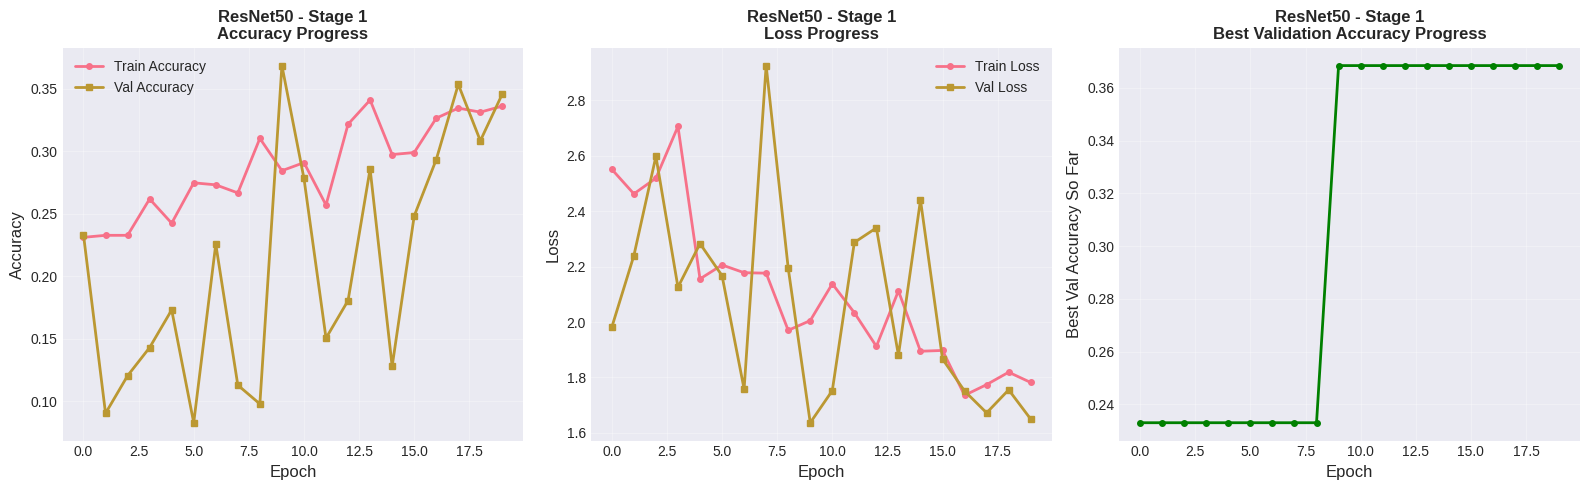


--- Stage 2: Fine-Tuning ---
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.2084 - loss: 2.3199

39/39 ━━━━━━━━━━━━━━━━━━━━ 54s 880ms/step - accuracy: 0.2086 - loss: 2.3231 - val_accuracy: 0.2556 - val_loss: 2.1220 - learning_rate: 1.0000e-04
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.2301 - loss: 2.1866

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 526ms/step - accuracy: 0.2300 - loss: 2.1887 - val_accuracy: 0.3684 - val_loss: 1.8367 - learning_rate: 1.0000e-04
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step - accuracy: 0.2902 - loss: 2.1293 - val_accuracy: 0.2857 - val_loss: 1.8859 - learning_rate: 1.0000e-04
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.2551 - loss: 1.9828 - val_accuracy: 0.3383 - val_loss: 1.7393 - learning_rate: 1.0000e-04
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - accuracy: 0.2940 - loss: 1.8641 - val_accuracy: 0.2707 - val_loss: 1.9834 - learning_rate: 1.0000e-04
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 528ms/step - accuracy: 0.2946 - loss: 2.0862 - val_accuracy: 0.3008 - val_loss: 1.6678 - learning_rate: 1.0000e-04
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 500ms/step - accuracy: 0.3011 - loss: 2.0443 - val_accuracy: 0.2481 - val_loss: 1.8578 - learning_rate: 1.0000e-04
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 489ms/step - accuracy: 0.26

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 518ms/step - accuracy: 0.3376 - loss: 1.8712 - val_accuracy: 0.3835 - val_loss: 1.7528 - learning_rate: 1.0000e-04
Epoch 11/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 485ms/step - accuracy: 0.3164 - loss: 1.7149 - val_accuracy: 0.3534 - val_loss: 1.8013 - learning_rate: 1.0000e-04
Epoch 12/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 494ms/step - accuracy: 0.2986 - loss: 1.9785 - val_accuracy: 0.3684 - val_loss: 1.7985 - learning_rate: 1.0000e-04
Epoch 13/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.3037 - loss: 1.7458

39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 581ms/step - accuracy: 0.3045 - loss: 1.7479 - val_accuracy: 0.4060 - val_loss: 1.6043 - learning_rate: 1.0000e-04
Epoch 14/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - accuracy: 0.3255 - loss: 1.8662 - val_accuracy: 0.2782 - val_loss: 1.9986 - learning_rate: 1.0000e-04
Epoch 15/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.3022 - loss: 1.7573

39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 581ms/step - accuracy: 0.3022 - loss: 1.7585 - val_accuracy: 0.4135 - val_loss: 1.7631 - learning_rate: 1.0000e-04
Epoch 16/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 494ms/step - accuracy: 0.3027 - loss: 1.8668 - val_accuracy: 0.3759 - val_loss: 1.7438 - learning_rate: 1.0000e-04
Epoch 17/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 509ms/step - accuracy: 0.2890 - loss: 1.8063 - val_accuracy: 0.3158 - val_loss: 1.9838 - learning_rate: 1.0000e-04
Epoch 18/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.3374 - loss: 1.8222
Epoch 18: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 504ms/step - accuracy: 0.3371 - loss: 1.8237 - val_accuracy: 0.3910 - val_loss: 1.9087 - learning_rate: 1.0000e-04
Epoch 19/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 488ms/step - accuracy: 0.3061 - loss: 1.9121 - val_accuracy: 0.3459 - val_loss: 1.7920 - learning_rate: 5.0000e-05
Epoch 20/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 505ms/step - accuracy: 0.36

39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 690ms/step - accuracy: 0.3365 - loss: 1.8117 - val_accuracy: 0.4361 - val_loss: 1.7208 - learning_rate: 2.5000e-05
Epoch 27/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 499ms/step - accuracy: 0.3602 - loss: 1.6789 - val_accuracy: 0.3759 - val_loss: 1.8806 - learning_rate: 2.5000e-05
Epoch 28/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.3813 - loss: 1.6488
Epoch 28: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 502ms/step - accuracy: 0.3809 - loss: 1.6498 - val_accuracy: 0.3158 - val_loss: 1.8516 - learning_rate: 2.5000e-05
Epoch 29/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 505ms/step - accuracy: 0.3854 - loss: 1.5809 - val_accuracy: 0.3459 - val_loss: 1.7977 - learning_rate: 1.2500e-05
Epoch 30/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 498ms/step - accuracy: 0.3610 - loss: 1.5969 - val_accuracy: 0.3835 - val_loss: 1.7374 - learning_rate: 1.2500e-05
Epoch 31/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 485ms/step - accuracy: 0.33

39/39 ━━━━━━━━━━━━━━━━━━━━ 27s 687ms/step - accuracy: 0.4305 - loss: 1.5514 - val_accuracy: 0.4511 - val_loss: 1.6077 - learning_rate: 1.2500e-05
Epoch 34/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 486ms/step - accuracy: 0.3655 - loss: 1.6442 - val_accuracy: 0.4361 - val_loss: 1.5867 - learning_rate: 6.2500e-06
Epoch 35/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 506ms/step - accuracy: 0.3829 - loss: 1.5947 - val_accuracy: 0.4361 - val_loss: 1.6287 - learning_rate: 6.2500e-06
Epoch 36/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 506ms/step - accuracy: 0.4219 - loss: 1.4263 - val_accuracy: 0.4286 - val_loss: 1.6390 - learning_rate: 6.2500e-06
Epoch 37/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 479ms/step - accuracy: 0.3874 - loss: 1.7620 - val_accuracy: 0.3985 - val_loss: 1.6612 - learning_rate: 6.2500e-06
Epoch 38/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 506ms/step - accuracy: 0.4192 - loss: 1.5592 - val_accuracy: 0.3835 - val_loss: 1.6517 - learning_rate: 6.2500e-06
Epoch 39/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy:

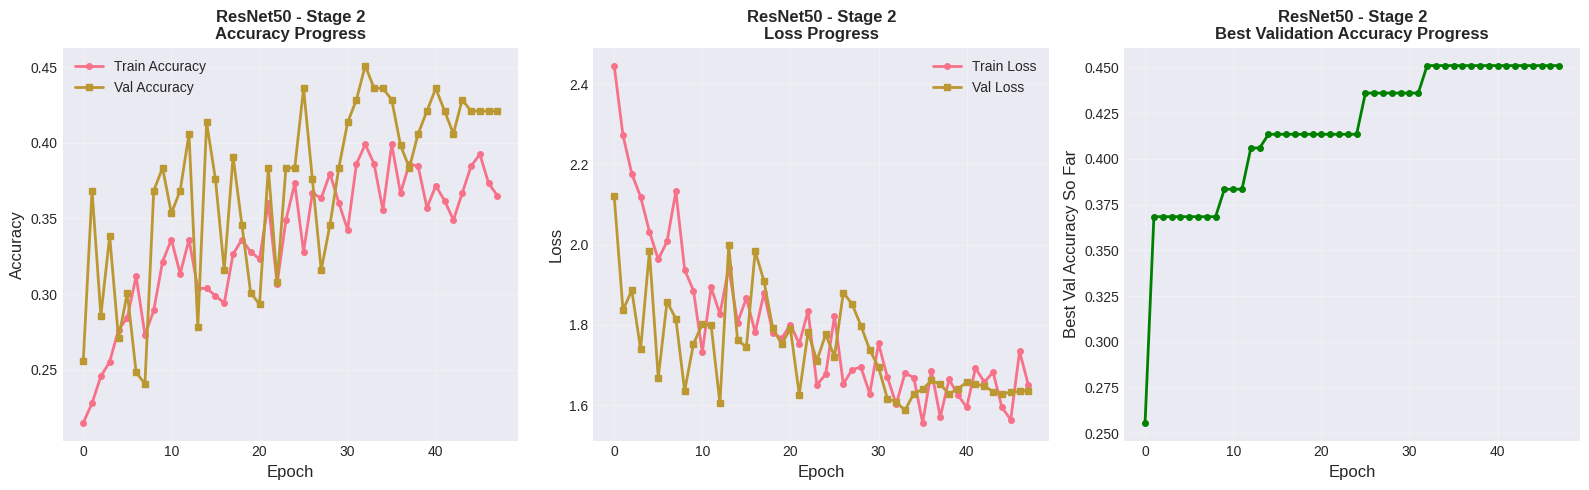


ResNet50 - TEST RESULTS
Test Loss: 1.4413
Test Accuracy: 45.11%
Weighted F1-Score: 45.23%
Macro F1-Score: 40.66%

Classification Report:
                   precision    recall  f1-score   support

        Bird-drop       0.46      0.21      0.29        28
            Clean       0.57      0.59      0.58        29
            Dusty       0.59      0.36      0.44        28
Electrical-damage       0.39      0.75      0.51        16
              New       0.07      0.33      0.11         3
  Physical-Damage       0.33      0.27      0.30        11
     Snow-Covered       0.61      0.61      0.61        18

         accuracy                           0.45       133
        macro avg       0.43      0.45      0.41       133
     weighted avg       0.50      0.45      0.45       133



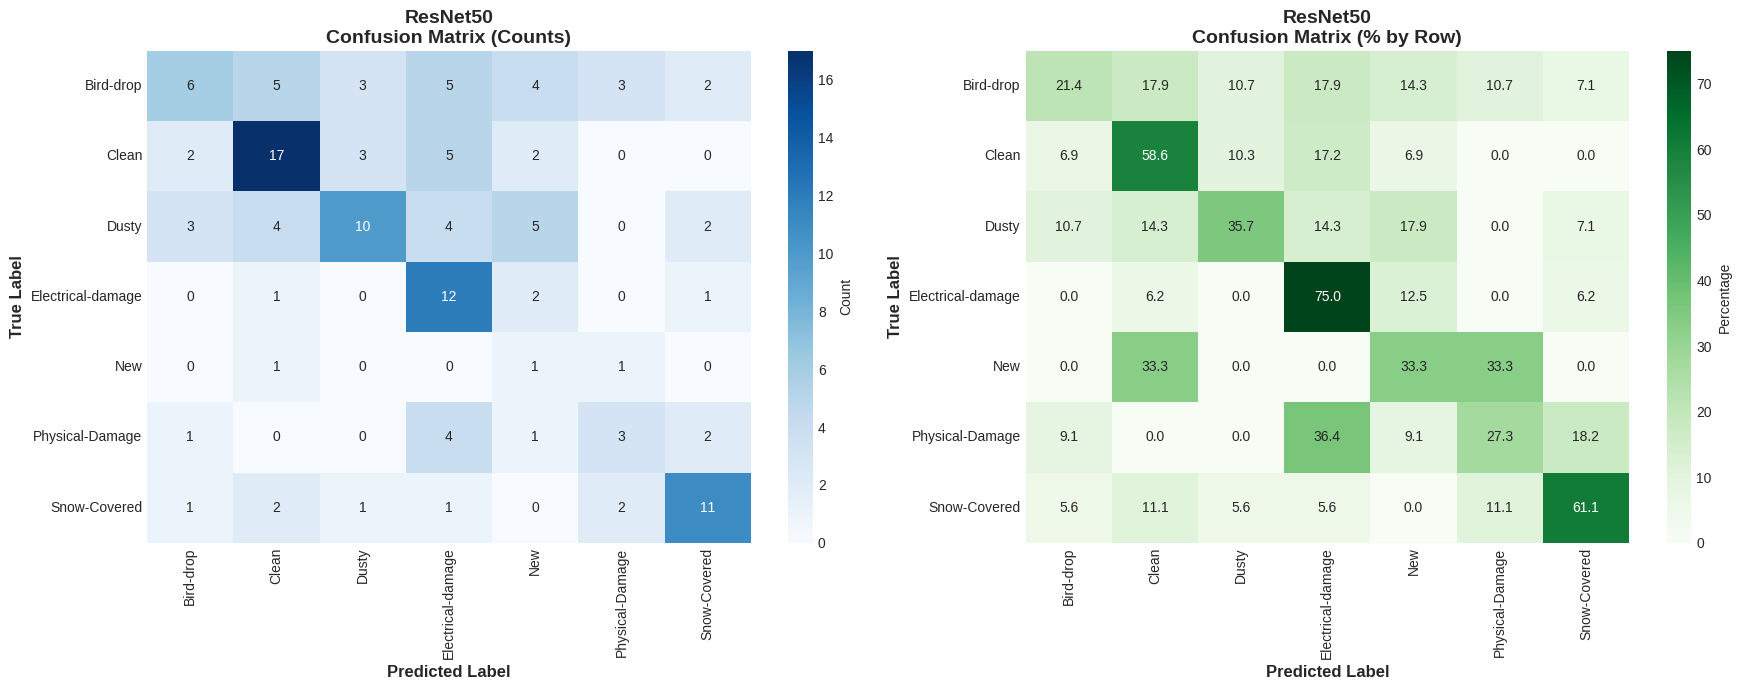

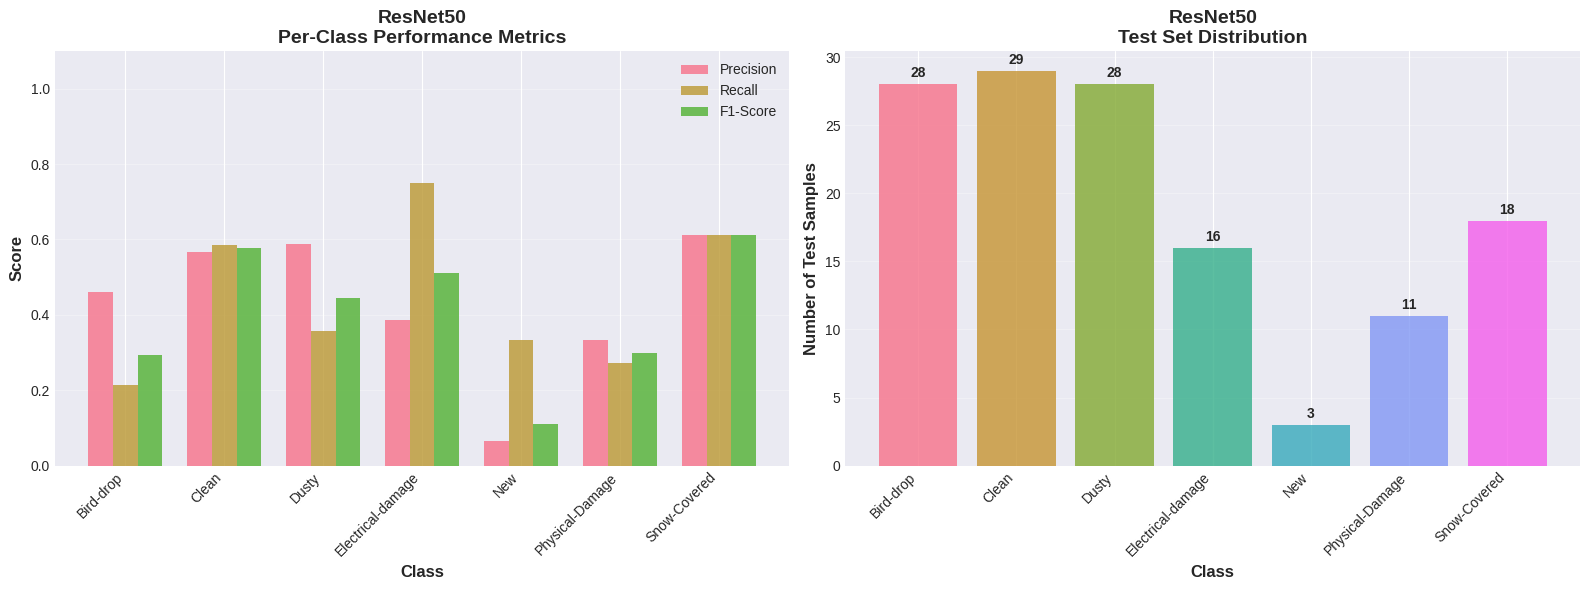

In [6]:
# STAGE 1
print("\n--- Stage 1: Training Top Layers ---")
model_resnet.compile(optimizer=Adam(learning_rate=INITIAL_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_resnet_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('resnet50_stage1.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_resnet_s1 = model_resnet.fit(
    train_generator, epochs=EPOCHS_STAGE1, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=callbacks_resnet_s1, verbose=1
)

plot_training_history(history_resnet_s1, "Stage 1", "ResNet50")

# STAGE 2
print("\n--- Stage 2: Fine-Tuning ---")
model_resnet.load_weights('resnet50_stage1.h5')

for layer in base_resnet.layers[143:]:
    layer.trainable = True

model_resnet.compile(optimizer=Adam(learning_rate=FINETUNE_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_resnet_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('resnet50_best.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_resnet_s2 = model_resnet.fit(
    train_generator, epochs=EPOCHS_STAGE2, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=callbacks_resnet_s2, verbose=1
)

plot_training_history(history_resnet_s2, "Stage 2", "ResNet50")

model_resnet.load_weights('resnet50_best.h5')
acc_resnet, f1_resnet = evaluate_and_report(model_resnet, test_generator, "ResNet50", sorted_labels)
results_dict['ResNet50'] = {'accuracy': acc_resnet, 'f1_weighted': f1_resnet}


In [7]:
# ==============================================================================
# MODEL 2: EfficientNetB0
# ==============================================================================

print("\n" + "="*70)
print("MODEL 2: EfficientNetB0 - TWO STAGE TRAINING")
print("="*70)

base_efficient = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
for layer in base_efficient.layers:
    layer.trainable = False

x = base_efficient.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions_efficient = Dense(NUM_CLASSES, activation='softmax')(x)

model_efficient = Model(inputs=base_efficient.input, outputs=predictions_efficient)


MODEL 2: EfficientNetB0 - TWO STAGE TRAINING
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



--- Stage 1: Training Top Layers ---
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.1501 - loss: 2.3306

39/39 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.1500 - loss: 2.3307 - val_accuracy: 0.1429 - val_loss: 1.9459 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 478ms/step - accuracy: 0.1662 - loss: 2.2194 - val_accuracy: 0.0752 - val_loss: 1.9807 - learning_rate: 0.0010
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 473ms/step - accuracy: 0.1759 - loss: 2.3341 - val_accuracy: 0.0150 - val_loss: 2.1735 - learning_rate: 0.0010
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.1069 - loss: 2.1769
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.


39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 510ms/step - accuracy: 0.1072 - loss: 2.1788 - val_accuracy: 0.2180 - val_loss: 2.0170 - learning_rate: 0.0010
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 467ms/step - accuracy: 0.1286 - loss: 2.1156 - val_accuracy: 0.1128 - val_loss: 1.9143 - learning_rate: 5.0000e-04
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - accuracy: 0.1416 - loss: 2.0837 - val_accuracy: 0.2180 - val_loss: 1.9179 - learning_rate: 5.0000e-04
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 471ms/step - accuracy: 0.1448 - loss: 2.1293 - val_accuracy: 0.1128 - val_loss: 1.8506 - learning_rate: 5.0000e-04
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 458ms/step - accuracy: 0.1568 - loss: 1.9986 - val_accuracy: 0.2180 - val_loss: 1.8942 - learning_rate: 5.0000e-04
Epoch 9/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 475ms/step - accuracy: 0.1385 - loss: 2.1365 - val_accuracy: 0.2105 - val_loss: 1.8691 - learning_rate: 5.0000e-04
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.1307 -

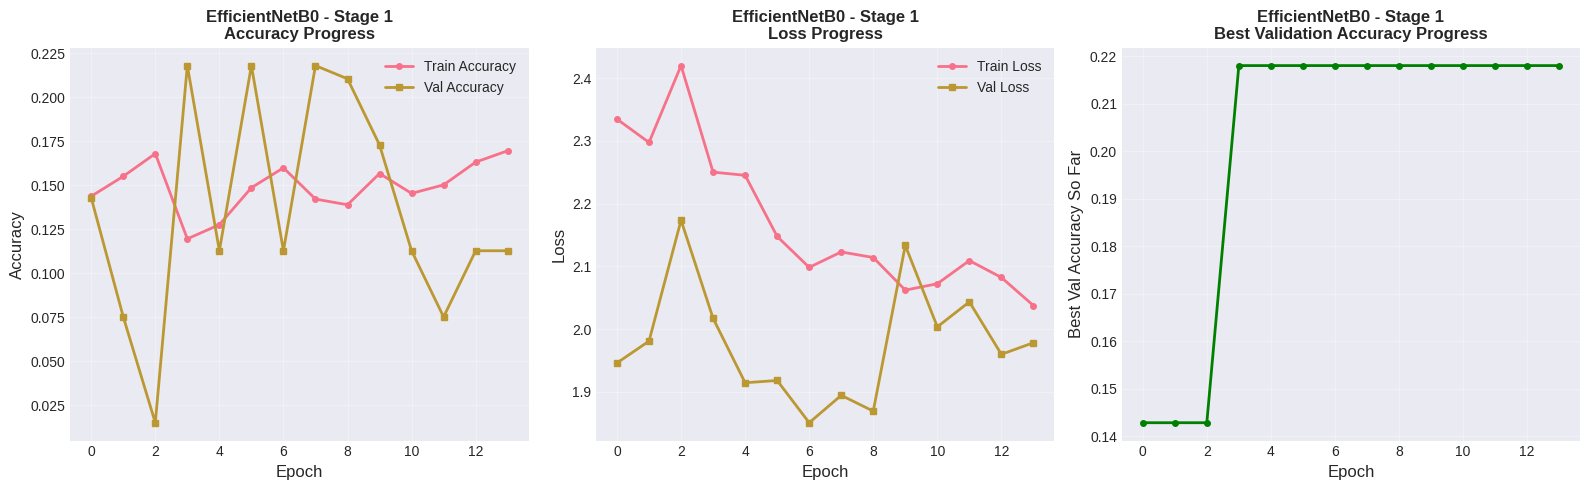


--- Stage 2: Fine-Tuning ---
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1930 - loss: 2.3316

39/39 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.1931 - loss: 2.3377 - val_accuracy: 0.2180 - val_loss: 2.0930 - learning_rate: 1.0000e-04
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 530ms/step - accuracy: 0.2837 - loss: 1.9422 - val_accuracy: 0.2180 - val_loss: 2.0777 - learning_rate: 1.0000e-04
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 504ms/step - accuracy: 0.3028 - loss: 2.0418 - val_accuracy: 0.2180 - val_loss: 2.1366 - learning_rate: 1.0000e-04
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 486ms/step - accuracy: 0.3407 - loss: 1.8418 - val_accuracy: 0.0752 - val_loss: 2.4024 - learning_rate: 1.0000e-04
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 508ms/step - accuracy: 0.3370 - loss: 1.7448 - val_accuracy: 0.0902 - val_loss: 2.8642 - learning_rate: 1.0000e-04
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 486ms/step - accuracy: 0.3603 - loss: 1.5692 - val_accuracy: 0.0526 - val_loss: 3.4638 - learning_rate: 1.0000e-04
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.3852 

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 509ms/step - accuracy: 0.5263 - loss: 1.1322 - val_accuracy: 0.2632 - val_loss: 2.3378 - learning_rate: 5.0000e-05
Epoch 12/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.5386 - loss: 1.1896
Epoch 12: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 506ms/step - accuracy: 0.5381 - loss: 1.1906 - val_accuracy: 0.2256 - val_loss: 2.4514 - learning_rate: 5.0000e-05
Epoch 13/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5253 - loss: 1.3180

39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 591ms/step - accuracy: 0.5253 - loss: 1.3168 - val_accuracy: 0.3609 - val_loss: 2.1457 - learning_rate: 2.5000e-05
Epoch 14/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.5202 - loss: 1.2594

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 513ms/step - accuracy: 0.5212 - loss: 1.2585 - val_accuracy: 0.4511 - val_loss: 1.6564 - learning_rate: 2.5000e-05
Epoch 15/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - accuracy: 0.5658 - loss: 0.9998 - val_accuracy: 0.4060 - val_loss: 1.8535 - learning_rate: 2.5000e-05
Epoch 16/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.5275 - loss: 1.1396

...

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.5467 - loss: 1.1340 - val_accuracy: 0.5038 - val_loss: 1.5786 - learning_rate: 2.5000e-05
Epoch 18/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.5797 - loss: 1.0478

39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 529ms/step - accuracy: 0.5795 - loss: 1.0494 - val_accuracy: 0.5113 - val_loss: 1.4545 - learning_rate: 2.5000e-05
Epoch 19/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.5849 - loss: 1.1696 - val_accuracy: 0.5038 - val_loss: 1.5081 - learning_rate: 2.5000e-05
Epoch 20/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.5804 - loss: 1.1391

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 511ms/step - accuracy: 0.5803 - loss: 1.1394 - val_accuracy: 0.5564 - val_loss: 1.2516 - learning_rate: 2.5000e-05
Epoch 21/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.5223 - loss: 1.2705

39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 531ms/step - accuracy: 0.5231 - loss: 1.2676 - val_accuracy: 0.5940 - val_loss: 1.2786 - learning_rate: 2.5000e-05
Epoch 22/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 506ms/step - accuracy: 0.5796 - loss: 1.0564 - val_accuracy: 0.5714 - val_loss: 1.3879 - learning_rate: 2.5000e-05
Epoch 23/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step - accuracy: 0.5706 - loss: 1.0366 - val_accuracy: 0.4361 - val_loss: 2.0950 - learning_rate: 2.5000e-05
Epoch 24/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 510ms/step - accuracy: 0.5954 - loss: 1.0750 - val_accuracy: 0.3835 - val_loss: 2.2814 - learning_rate: 2.5000e-05
Epoch 25/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.5986 - loss: 0.9709
Epoch 25: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 524ms/step - accuracy: 0.5986 - loss: 0.9711 - val_accuracy: 0.4211 - val_loss: 2.0174 - learning_rate: 2.5000e-05
Epoch 26/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - accuracy: 0.62

39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 534ms/step - accuracy: 0.5805 - loss: 0.9965 - val_accuracy: 0.6241 - val_loss: 1.1445 - learning_rate: 1.2500e-05
Epoch 28/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 498ms/step - accuracy: 0.6110 - loss: 0.9634 - val_accuracy: 0.6165 - val_loss: 1.1191 - learning_rate: 1.2500e-05
Epoch 29/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 517ms/step - accuracy: 0.6300 - loss: 0.8719 - val_accuracy: 0.5865 - val_loss: 1.1986 - learning_rate: 1.2500e-05
Epoch 30/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 514ms/step - accuracy: 0.6129 - loss: 0.8711 - val_accuracy: 0.5263 - val_loss: 1.3267 - learning_rate: 1.2500e-05
Epoch 31/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 497ms/step - accuracy: 0.6060 - loss: 1.0618 - val_accuracy: 0.4887 - val_loss: 1.4716 - learning_rate: 1.2500e-05
Epoch 32/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 509ms/step - accuracy: 0.5902 - loss: 1.0343 - val_accuracy: 0.4586 - val_loss: 1.7133 - learning_rate: 1.2500e-05
Epoch 33/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy:

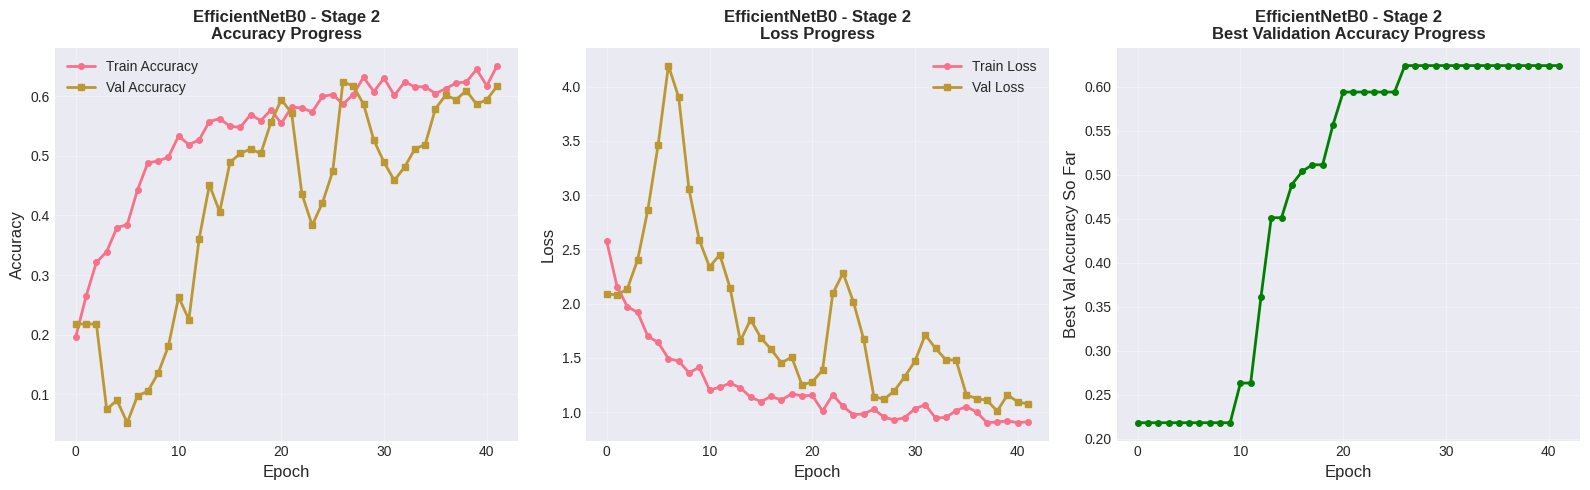


EfficientNetB0 - TEST RESULTS
Test Loss: 1.1284
Test Accuracy: 60.90%
Weighted F1-Score: 63.36%
Macro F1-Score: 53.73%

Classification Report:
                   precision    recall  f1-score   support

        Bird-drop       0.79      0.39      0.52        28
            Clean       0.69      0.76      0.72        29
            Dusty       0.72      0.64      0.68        28
Electrical-damage       0.62      0.81      0.70        16
              New       0.00      0.00      0.00         3
  Physical-Damage       0.30      0.27      0.29        11
     Snow-Covered       0.93      0.78      0.85        18

         accuracy                           0.61       133
        macro avg       0.58      0.52      0.54       133
     weighted avg       0.69      0.61      0.63       133



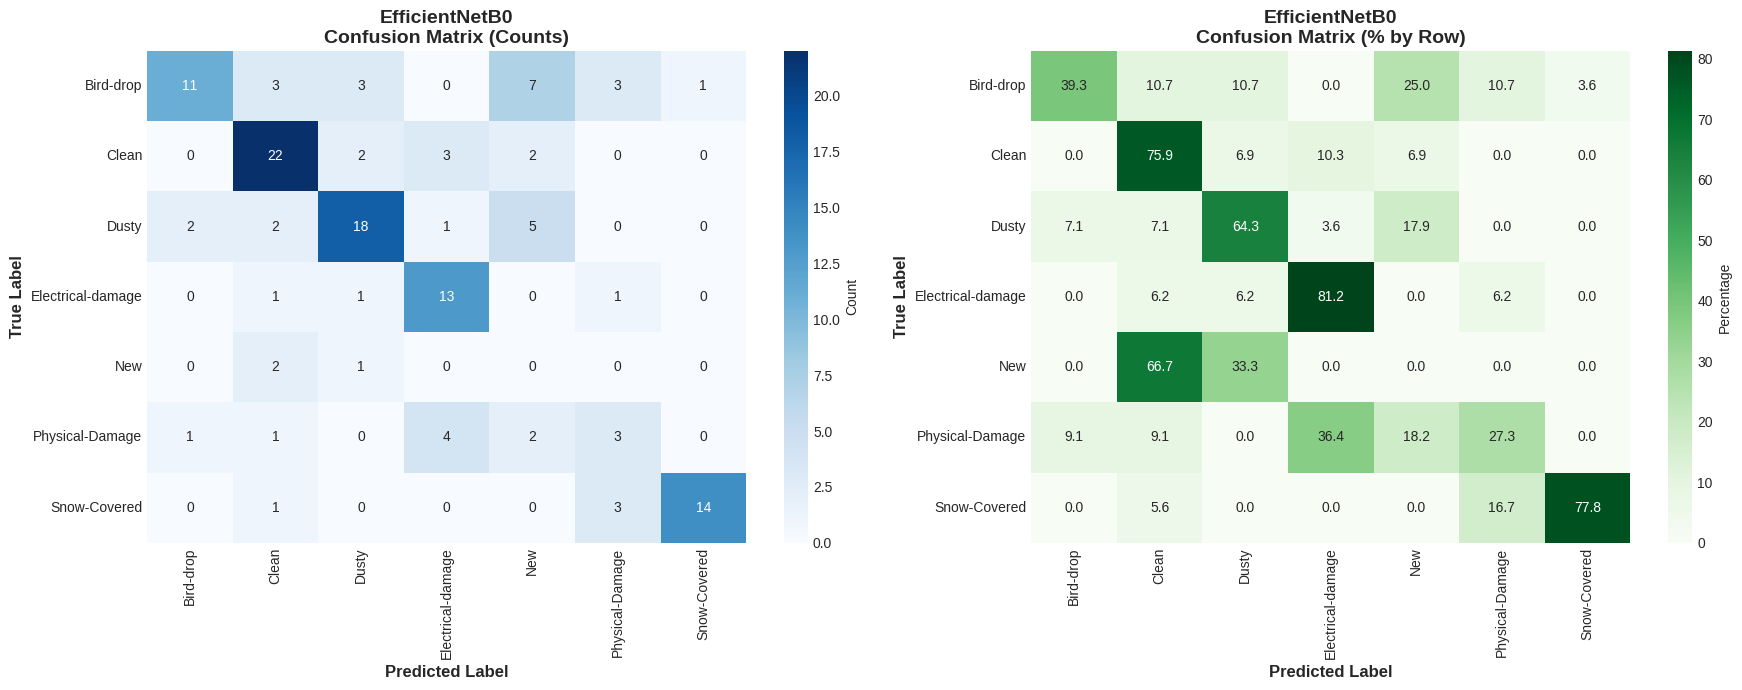

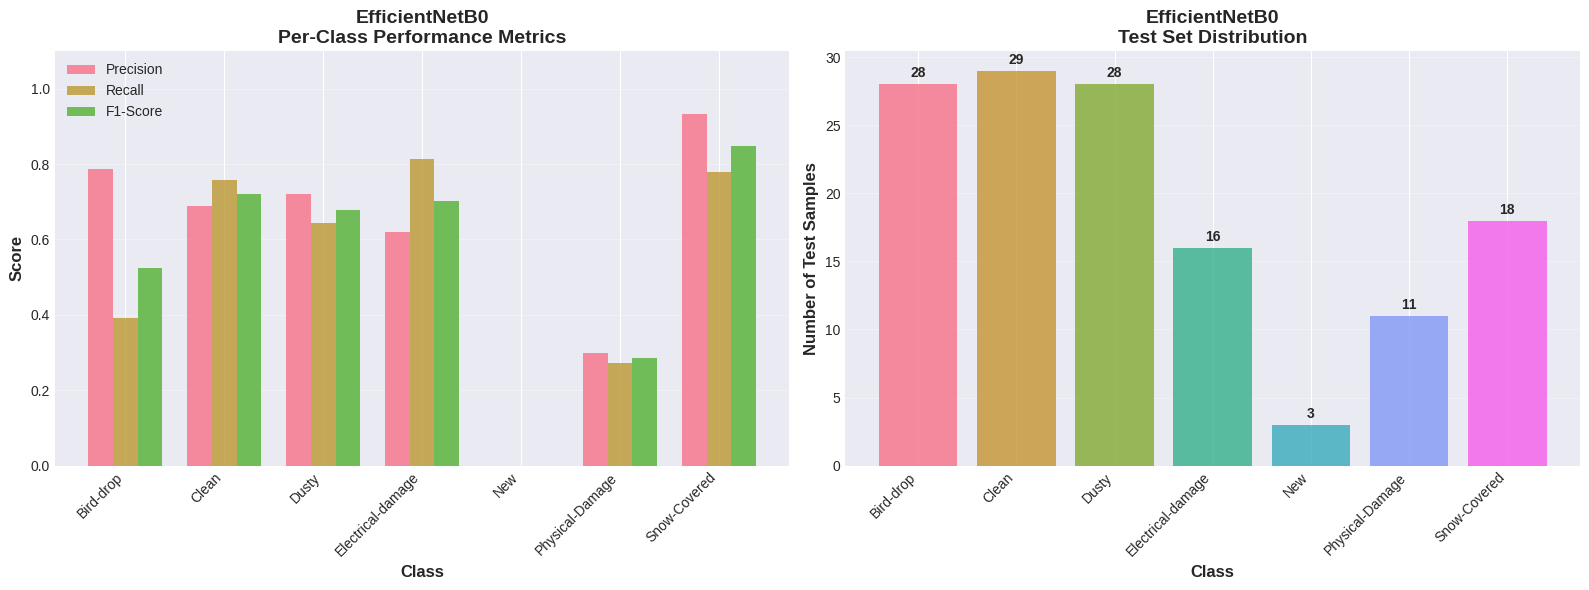

In [8]:
# STAGE 1
print("\n--- Stage 1: Training Top Layers ---")
model_efficient.compile(optimizer=Adam(learning_rate=INITIAL_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_efficient_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('efficient_stage1.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_efficient_s1 = model_efficient.fit(
    train_generator, epochs=EPOCHS_STAGE1, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=callbacks_efficient_s1, verbose=1
)

plot_training_history(history_efficient_s1, "Stage 1", "EfficientNetB0")

# STAGE 2
print("\n--- Stage 2: Fine-Tuning ---")
model_efficient.load_weights('efficient_stage1.h5')

for layer in base_efficient.layers:
    layer.trainable = True

model_efficient.compile(optimizer=Adam(learning_rate=FINETUNE_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_efficient_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('efficient_best.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_efficient_s2 = model_efficient.fit(
    train_generator, epochs=EPOCHS_STAGE2, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=callbacks_efficient_s2, verbose=1
)

plot_training_history(history_efficient_s2, "Stage 2", "EfficientNetB0")

model_efficient.load_weights('efficient_best.h5')
acc_efficient, f1_efficient = evaluate_and_report(model_efficient, test_generator, "EfficientNetB0", sorted_labels)
results_dict['EfficientNetB0'] = {'accuracy': acc_efficient, 'f1_weighted': f1_efficient}

In [9]:
# ==============================================================================
# MODEL 3: VGG16
# ==============================================================================

print("\n" + "="*70)
print("MODEL 3: VGG16 - TWO STAGE TRAINING")
print("="*70)

base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
for layer in base_vgg.layers:
    layer.trainable = False

x = base_vgg.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model_vgg = Model(inputs=base_vgg.input, outputs=predictions)


MODEL 3: VGG16 - TWO STAGE TRAINING
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



--- Stage 1: Training Top Layers ---
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.2817 - loss: 2.0212

39/39 ━━━━━━━━━━━━━━━━━━━━ 45s 848ms/step - accuracy: 0.2829 - loss: 2.0225 - val_accuracy: 0.2707 - val_loss: 1.8312 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 490ms/step - accuracy: 0.4391 - loss: 1.5381 - val_accuracy: 0.2481 - val_loss: 1.7042 - learning_rate: 0.0010
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.4291 - loss: 1.6154

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 526ms/step - accuracy: 0.4290 - loss: 1.6146 - val_accuracy: 0.3158 - val_loss: 1.5632 - learning_rate: 0.0010
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.5126 - loss: 1.4984

39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 488ms/step - accuracy: 0.5122 - loss: 1.4965 - val_accuracy: 0.3534 - val_loss: 1.5662 - learning_rate: 0.0010
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.4922 - loss: 1.3397

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.4924 - loss: 1.3403 - val_accuracy: 0.4060 - val_loss: 1.5300 - learning_rate: 0.0010
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.5239 - loss: 1.2465

...

39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 491ms/step - accuracy: 0.5834 - loss: 1.0974 - val_accuracy: 0.5940 - val_loss: 1.0174 - learning_rate: 0.0010
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.5690 - loss: 1.0655

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 510ms/step - accuracy: 0.5687 - loss: 1.0691 - val_accuracy: 0.6165 - val_loss: 0.9538 - learning_rate: 0.0010
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.6164 - loss: 0.9865

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 508ms/step - accuracy: 0.6157 - loss: 0.9882 - val_accuracy: 0.6241 - val_loss: 1.0131 - learning_rate: 0.0010
Epoch 12/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - accuracy: 0.5888 - loss: 1.0524 - val_accuracy: 0.4962 - val_loss: 1.4109 - learning_rate: 0.0010
Epoch 13/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.5283 - loss: 1.1426
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 503ms/step - accuracy: 0.5286 - loss: 1.1429 - val_accuracy: 0.5414 - val_loss: 1.2598 - learning_rate: 0.0010
Epoch 14/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 485ms/step - accuracy: 0.5711 - loss: 1.0703 - val_accuracy: 0.6241 - val_loss: 1.0875 - learning_rate: 5.0000e-04
Epoch 15/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 528ms/step - accuracy: 0.5715 - loss: 1.0637 - val_accuracy: 0.6165 - val_loss: 1.0876 - learning_rate: 5.0000e-04
Epoch 16/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.5689 - loss: 1.

39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 494ms/step - accuracy: 0.6105 - loss: 0.9476 - val_accuracy: 0.6466 - val_loss: 1.0140 - learning_rate: 2.5000e-04
Epoch 18/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 506ms/step - accuracy: 0.6167 - loss: 0.9168 - val_accuracy: 0.6391 - val_loss: 1.0060 - learning_rate: 2.5000e-04
Epoch 19/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.6317 - loss: 0.7754
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 495ms/step - accuracy: 0.6313 - loss: 0.7781 - val_accuracy: 0.6767 - val_loss: 0.9823 - learning_rate: 2.5000e-04
Epoch 20/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 493ms/step - accuracy: 0.6371 - loss: 0.9595 - val_accuracy: 0.6541 - val_loss: 0.9776 - learning_rate: 1.2500e-04
Epoch 21/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 502ms/step - accuracy: 0.6607 - loss: 0.8106 - val_accuracy: 0.6391 - val_loss: 0.9883 - learning_rate: 1.2500e-04
Epoch 22/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6219 - loss: 0.8452
Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - accuracy: 0.6214 - loss: 0.8473 - val_accuracy: 0.6391 - val_loss: 1.0107 - learning_rate: 1.2500e-04
Epoch 23/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 502ms/step - accuracy: 0.6394 - loss: 0.8316 - val_accuracy: 0.6541 - val_loss: 1.0036 - learning_rate: 6.2500e-05
Epoch 24/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 491ms/step - accuracy: 0.594

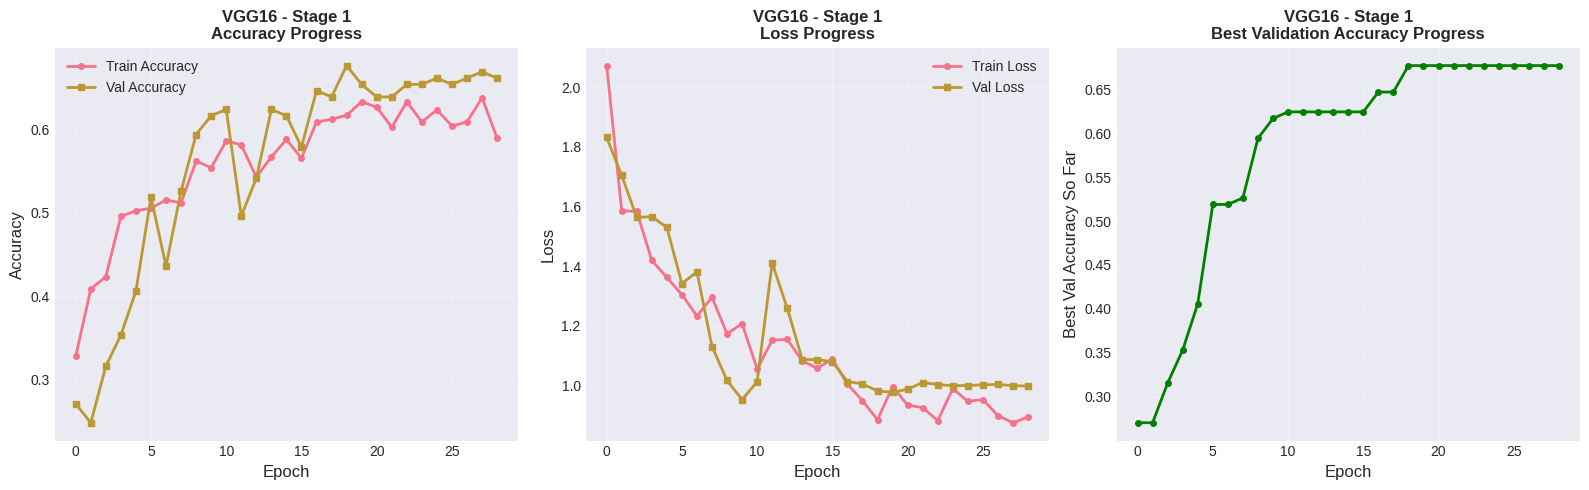


--- Stage 2: Fine-Tuning ---
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.5823 - loss: 1.0742

39/39 ━━━━━━━━━━━━━━━━━━━━ 31s 645ms/step - accuracy: 0.5816 - loss: 1.0804 - val_accuracy: 0.5489 - val_loss: 1.6224 - learning_rate: 1.0000e-04
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 32s 505ms/step - accuracy: 0.5373 - loss: 1.3629 - val_accuracy: 0.3008 - val_loss: 3.7388 - learning_rate: 1.0000e-04
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.5283 - loss: 1.1064

39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 645ms/step - accuracy: 0.5292 - loss: 1.1065 - val_accuracy: 0.5564 - val_loss: 1.7555 - learning_rate: 1.0000e-04
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.6009 - loss: 1.0789

39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 509ms/step - accuracy: 0.6006 - loss: 1.0799 - val_accuracy: 0.5714 - val_loss: 2.7552 - learning_rate: 1.0000e-04
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 518ms/step - accuracy: 0.6114 - loss: 1.0438 - val_accuracy: 0.5188 - val_loss: 2.5312 - learning_rate: 1.0000e-04
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.5950 - loss: 1.0968
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 498ms/step - accuracy: 0.5954 - loss: 1.0950 - val_accuracy: 0.5639 - val_loss: 1.7750 - learning_rate: 1.0000e-04
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 515ms/step - accuracy: 0.6123 - loss: 0.9984 - val_accuracy: 0.5489 - val_loss: 1.8265 - learning_rate: 5.0000e-05
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.6563 - loss: 0.8410

39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 534ms/step - accuracy: 0.6564 - loss: 0.8404 - val_accuracy: 0.6466 - val_loss: 1.0191 - learning_rate: 5.0000e-05
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 496ms/step - accuracy: 0.6755 - loss: 0.8250 - val_accuracy: 0.5338 - val_loss: 1.4610 - learning_rate: 5.0000e-05
Epoch 10/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 500ms/step - accuracy: 0.6781 - loss: 0.7814 - val_accuracy: 0.6241 - val_loss: 1.0314 - learning_rate: 5.0000e-05
Epoch 11/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 518ms/step - accuracy: 0.7559 - loss: 0.5846 - val_accuracy: 0.6466 - val_loss: 1.0754 - learning_rate: 5.0000e-05
Epoch 12/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.7484 - loss: 0.6254

39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 643ms/step - accuracy: 0.7477 - loss: 0.6269 - val_accuracy: 0.6541 - val_loss: 0.9242 - learning_rate: 5.0000e-05
Epoch 13/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 493ms/step - accuracy: 0.7219 - loss: 0.6568 - val_accuracy: 0.6090 - val_loss: 1.1232 - learning_rate: 5.0000e-05
Epoch 14/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 515ms/step - accuracy: 0.7301 - loss: 0.6262 - val_accuracy: 0.5789 - val_loss: 1.2632 - learning_rate: 5.0000e-05
Epoch 15/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 495ms/step - accuracy: 0.7726 - loss: 0.5897 - val_accuracy: 0.6015 - val_loss: 1.2681 - learning_rate: 5.0000e-05
Epoch 16/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 508ms/step - accuracy: 0.7252 - loss: 0.6950 - val_accuracy: 0.6090 - val_loss: 1.2609 - learning_rate: 5.0000e-05
Epoch 17/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.7730 - loss: 0.5420
Epoch 17: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.


39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 666ms/step - accuracy: 0.7734 - loss: 0.5405 - val_accuracy: 0.6692 - val_loss: 0.9853 - learning_rate: 5.0000e-05
Epoch 18/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 531ms/step - accuracy: 0.7535 - loss: 0.5227 - val_accuracy: 0.6316 - val_loss: 1.1259 - learning_rate: 2.5000e-05
Epoch 19/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 503ms/step - accuracy: 0.7686 - loss: 0.5951 - val_accuracy: 0.6241 - val_loss: 1.2804 - learning_rate: 2.5000e-05
Epoch 20/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 497ms/step - accuracy: 0.8011 - loss: 0.4508 - val_accuracy: 0.6541 - val_loss: 1.0933 - learning_rate: 2.5000e-05
Epoch 21/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 507ms/step - accuracy: 0.8005 - loss: 0.5265 - val_accuracy: 0.6090 - val_loss: 1.1531 - learning_rate: 2.5000e-05
Epoch 22/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8068 - loss: 0.4234
Epoch 22: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 638ms/step - accuracy: 0.8067 - loss: 0.4239 - val_accuracy: 0.7068 - val_loss: 0.9409 - learning_rate: 2.5000e-05
Epoch 23/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 493ms/step - accuracy: 0.8243 - loss: 0.4099 - val_accuracy: 0.6917 - val_loss: 0.9655 - learning_rate: 1.2500e-05
Epoch 24/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 518ms/step - accuracy: 0.8122 - loss: 0.4010 - val_accuracy: 0.6992 - val_loss: 0.9733 - learning_rate: 1.2500e-05
Epoch 25/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 494ms/step - accuracy: 0.8395 - loss: 0.4108 - val_accuracy: 0.6842 - val_loss: 1.0050 - learning_rate: 1.2500e-05
Epoch 26/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 516ms/step - accuracy: 0.8099 - loss: 0.3954 - val_accuracy: 0.7068 - val_loss: 0.9612 - learning_rate: 1.2500e-05
Epoch 27/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.7904 - loss: 0.4583
Epoch 27: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
39/39 ━━━━━━━━━━━━━━━━━━━━ 20s 512ms/step - accuracy: 0.790

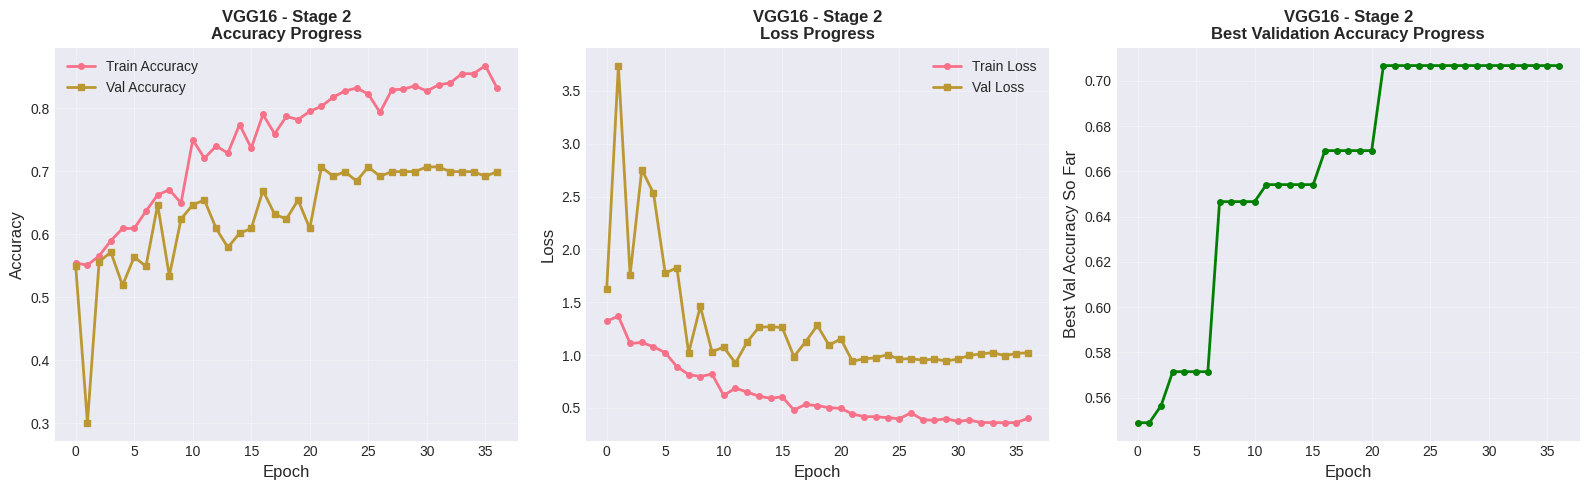


VGG16 - TEST RESULTS
Test Loss: 0.9912
Test Accuracy: 72.93%
Weighted F1-Score: 74.12%
Macro F1-Score: 68.46%

Classification Report:
                   precision    recall  f1-score   support

        Bird-drop       0.83      0.54      0.65        28
            Clean       0.85      0.79      0.82        29
            Dusty       0.58      0.79      0.67        28
Electrical-damage       0.76      0.81      0.79        16
              New       0.12      0.33      0.18         3
  Physical-Damage       0.89      0.73      0.80        11
     Snow-Covered       0.94      0.83      0.88        18

         accuracy                           0.73       133
        macro avg       0.71      0.69      0.68       133
     weighted avg       0.78      0.73      0.74       133



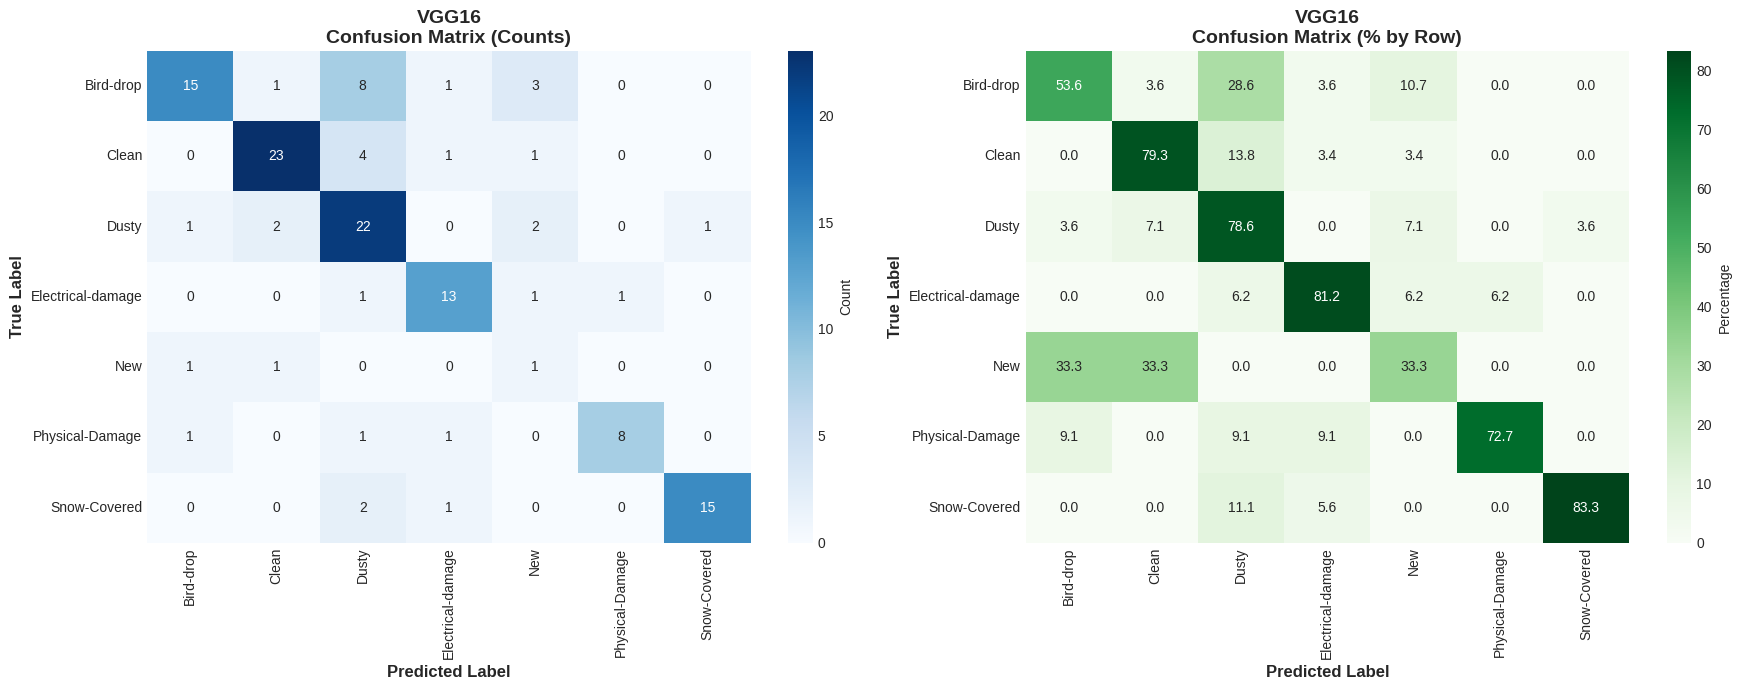

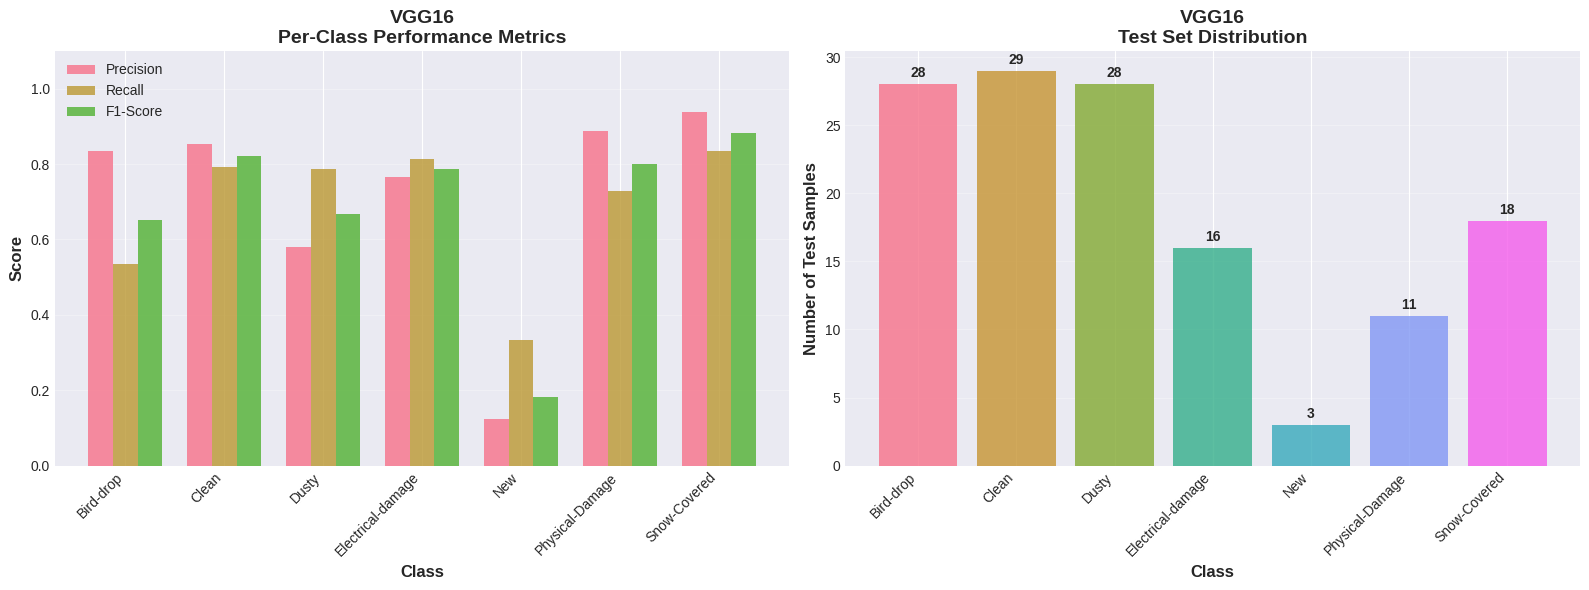

In [10]:
# STAGE 1
print("\n--- Stage 1: Training Top Layers ---")
model_vgg.compile(optimizer=Adam(learning_rate=INITIAL_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_vgg_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('vgg16_stage1.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_vgg_s1 = model_vgg.fit(
    train_generator, epochs=EPOCHS_STAGE1, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=callbacks_vgg_s1, verbose=1
)

plot_training_history(history_vgg_s1, "Stage 1", "VGG16")

# STAGE 2
print("\n--- Stage 2: Fine-Tuning ---")
model_vgg.load_weights('vgg16_stage1.h5')

for layer in base_vgg.layers[-4:]:
    layer.trainable = True

model_vgg.compile(optimizer=Adam(learning_rate=FINETUNE_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_vgg_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('vgg16_best.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_vgg_s2 = model_vgg.fit(
    train_generator, epochs=EPOCHS_STAGE2, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=callbacks_vgg_s2, verbose=1
)

plot_training_history(history_vgg_s2, "Stage 2", "VGG16")

model_vgg.load_weights('vgg16_best.h5')
acc_vgg, f1_vgg = evaluate_and_report(model_vgg, test_generator, "VGG16", sorted_labels)
results_dict['VGG16'] = {'accuracy': acc_vgg, 'f1_weighted': f1_vgg}


In [11]:
# ==============================================================================
# MODEL 4: InceptionV3 (299x299)
# ==============================================================================

print("\n" + "="*70)
print("MODEL 4: InceptionV3 - TWO STAGE TRAINING (299x299)")
print("="*70)

# Create generators for 299x299 input
train_gen_inception = train_datagen.flow_from_dataframe(
    df_train, x_col='filepath', y_col='label', target_size=(299, 299),
    batch_size=BATCH_SIZE, class_mode='categorical', classes=sorted_labels, seed=RANDOM_SEED
)

val_gen_inception = val_test_datagen.flow_from_dataframe(
    df_val, x_col='filepath', y_col='label', target_size=(299, 299),
    batch_size=BATCH_SIZE, class_mode='categorical', classes=sorted_labels, shuffle=False
)

test_gen_inception = val_test_datagen.flow_from_dataframe(
    df_test, x_col='filepath', y_col='label', target_size=(299, 299),
    batch_size=BATCH_SIZE, class_mode='categorical', classes=sorted_labels, shuffle=False
)

base_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
for layer in base_inception.layers:
    layer.trainable = False

x = base_inception.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
predictions_inception = Dense(NUM_CLASSES, activation='softmax')(x)

model_inception = Model(inputs=base_inception.input, outputs=predictions_inception)


MODEL 4: InceptionV3 - TWO STAGE TRAINING (299x299)
Found 619 validated image filenames belonging to 7 classes.
Found 133 validated image filenames belonging to 7 classes.
Found 133 validated image filenames belonging to 7 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



--- Stage 1: Training Top Layers ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 804ms/step - accuracy: 0.3592 - loss: 2.4078

39/39 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.3597 - loss: 2.4033 - val_accuracy: 0.2331 - val_loss: 2.1640 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.5219 - loss: 1.5038

39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 656ms/step - accuracy: 0.5213 - loss: 1.5060 - val_accuracy: 0.5338 - val_loss: 1.3519 - learning_rate: 0.0010
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 40s 640ms/step - accuracy: 0.5410 - loss: 1.2927 - val_accuracy: 0.5038 - val_loss: 1.6495 - learning_rate: 0.0010
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 636ms/step - accuracy: 0.5573 - loss: 1.2955 - val_accuracy: 0.4887 - val_loss: 1.3320 - learning_rate: 0.0010
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 633ms/step - accuracy: 0.5472 - loss: 1.1988 - val_accuracy: 0.4887 - val_loss: 1.9879 - learning_rate: 0.0010
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.6050 - loss: 1.2038

39/39 ━━━━━━━━━━━━━━━━━━━━ 31s 802ms/step - accuracy: 0.6047 - loss: 1.2042 - val_accuracy: 0.6992 - val_loss: 1.0339 - learning_rate: 0.0010
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 636ms/step - accuracy: 0.5694 - loss: 1.5042 - val_accuracy: 0.6241 - val_loss: 1.4034 - learning_rate: 0.0010
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.5827 - loss: 1.5501

39/39 ━━━━━━━━━━━━━━━━━━━━ 31s 816ms/step - accuracy: 0.5833 - loss: 1.5451 - val_accuracy: 0.7143 - val_loss: 0.9062 - learning_rate: 0.0010
Epoch 9/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 637ms/step - accuracy: 0.6134 - loss: 1.0494 - val_accuracy: 0.6015 - val_loss: 1.2853 - learning_rate: 0.0010
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 635ms/step - accuracy: 0.6188 - loss: 0.9153 - val_accuracy: 0.6617 - val_loss: 0.9671 - learning_rate: 0.0010
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.6568 - loss: 1.1686
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 632ms/step - accuracy: 0.6561 - loss: 1.1702 - val_accuracy: 0.6692 - val_loss: 0.9989 - learning_rate: 0.0010
Epoch 12/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 639ms/step - accuracy: 0.6076 - loss: 0.9774 - val_accuracy: 0.7143 - val_loss: 0.9033 - learning_rate: 5.0000e-04
Epoch 13/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.6421 - loss: 0.8574

39/39 ━━━━━━━━━━━━━━━━━━━━ 31s 800ms/step - accuracy: 0.6422 - loss: 0.8580 - val_accuracy: 0.7594 - val_loss: 0.7051 - learning_rate: 5.0000e-04
Epoch 14/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 644ms/step - accuracy: 0.7142 - loss: 0.7886 - val_accuracy: 0.7368 - val_loss: 0.7872 - learning_rate: 5.0000e-04
Epoch 15/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.6678 - loss: 0.8201

39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 668ms/step - accuracy: 0.6680 - loss: 0.8195 - val_accuracy: 0.7744 - val_loss: 0.6943 - learning_rate: 5.0000e-04
Epoch 16/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 644ms/step - accuracy: 0.7510 - loss: 0.6463 - val_accuracy: 0.7519 - val_loss: 0.7078 - learning_rate: 5.0000e-04
Epoch 17/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 656ms/step - accuracy: 0.7139 - loss: 0.7159 - val_accuracy: 0.7594 - val_loss: 0.6416 - learning_rate: 5.0000e-04
Epoch 18/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 24s 628ms/step - accuracy: 0.6721 - loss: 0.8208 - val_accuracy: 0.6617 - val_loss: 0.8999 - learning_rate: 5.0000e-04
Epoch 19/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 639ms/step - accuracy: 0.7080 - loss: 0.7061 - val_accuracy: 0.7669 - val_loss: 0.6689 - learning_rate: 5.0000e-04
Epoch 20/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.7177 - loss: 0.7455
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 637ms/step - accuracy: 0.71

39/39 ━━━━━━━━━━━━━━━━━━━━ 31s 801ms/step - accuracy: 0.7335 - loss: 0.7061 - val_accuracy: 0.7820 - val_loss: 0.6626 - learning_rate: 2.5000e-04
Epoch 22/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 630ms/step - accuracy: 0.7523 - loss: 0.5332 - val_accuracy: 0.7594 - val_loss: 0.7525 - learning_rate: 2.5000e-04
Epoch 23/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.7580 - loss: 0.5736
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 629ms/step - accuracy: 0.7570 - loss: 0.5750 - val_accuracy: 0.7368 - val_loss: 0.7241 - learning_rate: 2.5000e-04
Epoch 24/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 24s 629ms/step - accuracy: 0.7428 - loss: 0.6080 - val_accuracy: 0.7669 - val_loss: 0.6736 - learning_rate: 1.2500e-04
Epoch 25/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 657ms/step - accuracy: 0.7478 - loss: 0.5250 - val_accuracy: 0.7519 - val_loss: 0.7232 - learning_rate: 1.2500e-04
Epoch 26/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.743

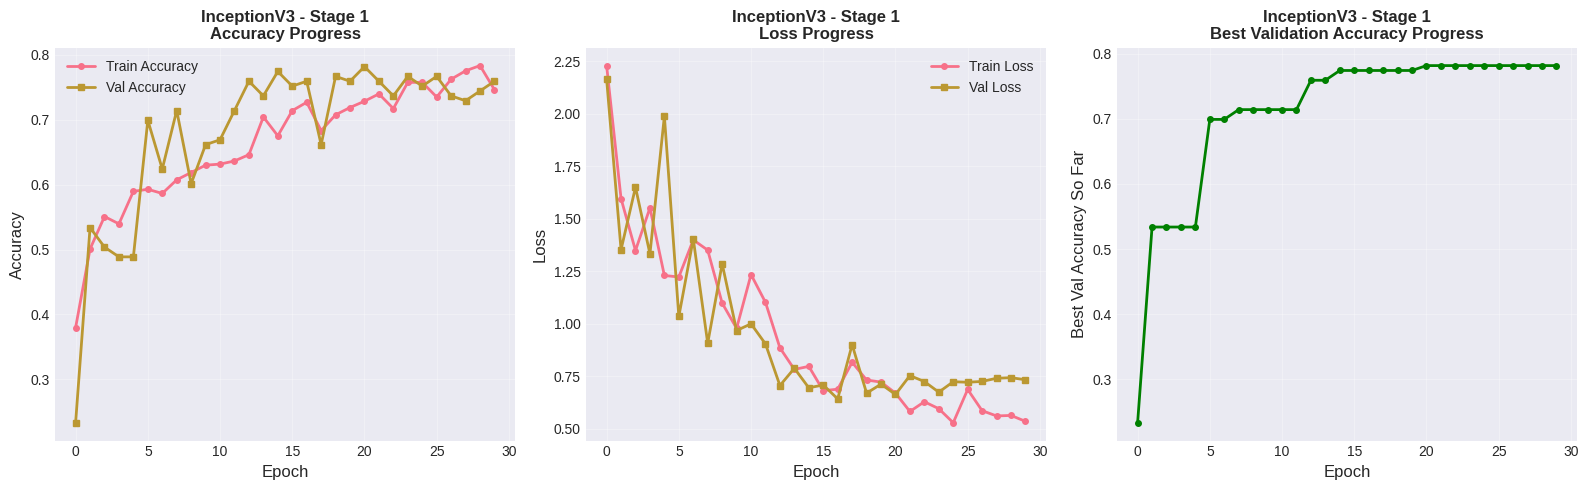


--- Stage 2: Fine-Tuning ---
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.6472 - loss: 1.0229

39/39 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.6473 - loss: 1.0237 - val_accuracy: 0.7068 - val_loss: 0.8964 - learning_rate: 1.0000e-04
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.7517 - loss: 0.5936

39/39 ━━━━━━━━━━━━━━━━━━━━ 33s 845ms/step - accuracy: 0.7513 - loss: 0.5977 - val_accuracy: 0.7218 - val_loss: 0.9262 - learning_rate: 1.0000e-04
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.6581 - loss: 1.1741

39/39 ━━━━━━━━━━━━━━━━━━━━ 32s 811ms/step - accuracy: 0.6585 - loss: 1.1685 - val_accuracy: 0.7820 - val_loss: 0.7510 - learning_rate: 1.0000e-04
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7798 - loss: 0.5224

39/39 ━━━━━━━━━━━━━━━━━━━━ 32s 818ms/step - accuracy: 0.7797 - loss: 0.5256 - val_accuracy: 0.8045 - val_loss: 0.7078 - learning_rate: 1.0000e-04
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 648ms/step - accuracy: 0.7537 - loss: 0.5751 - val_accuracy: 0.7970 - val_loss: 0.6966 - learning_rate: 1.0000e-04
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.7970 - loss: 0.5166

39/39 ━━━━━━━━━━━━━━━━━━━━ 38s 976ms/step - accuracy: 0.7968 - loss: 0.5178 - val_accuracy: 0.8120 - val_loss: 0.6833 - learning_rate: 1.0000e-04
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.8009 - loss: 0.3865

39/39 ━━━━━━━━━━━━━━━━━━━━ 33s 858ms/step - accuracy: 0.8019 - loss: 0.3858 - val_accuracy: 0.8195 - val_loss: 0.6486 - learning_rate: 1.0000e-04
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 660ms/step - accuracy: 0.8760 - loss: 0.3188 - val_accuracy: 0.8120 - val_loss: 0.7060 - learning_rate: 1.0000e-04
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 642ms/step - accuracy: 0.8158 - loss: 0.5208 - val_accuracy: 0.7669 - val_loss: 0.7302 - learning_rate: 1.0000e-04
Epoch 10/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 638ms/step - accuracy: 0.8717 - loss: 0.3951 - val_accuracy: 0.7970 - val_loss: 0.7500 - learning_rate: 1.0000e-04
Epoch 11/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 639ms/step - accuracy: 0.8755 - loss: 0.2780 - val_accuracy: 0.7970 - val_loss: 0.7551 - learning_rate: 1.0000e-04
Epoch 12/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.8387 - loss: 0.3721
Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 633ms/step - accuracy: 0.8389

39/39 ━━━━━━━━━━━━━━━━━━━━ 32s 830ms/step - accuracy: 0.9187 - loss: 0.2082 - val_accuracy: 0.8271 - val_loss: 0.7017 - learning_rate: 2.5000e-05
Epoch 22/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9017 - loss: 0.2195
Epoch 22: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 28s 704ms/step - accuracy: 0.9022 - loss: 0.2186 - val_accuracy: 0.8271 - val_loss: 0.7217 - learning_rate: 2.5000e-05
Epoch 23/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 648ms/step - accuracy: 0.9011 - loss: 0.1702 - val_accuracy: 0.8195 - val_loss: 0.7094 - learning_rate: 1.2500e-05
Epoch 24/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9185 - loss: 0.1806

39/39 ━━━━━━━━━━━━━━━━━━━━ 34s 874ms/step - accuracy: 0.9185 - loss: 0.1808 - val_accuracy: 0.8346 - val_loss: 0.6961 - learning_rate: 1.2500e-05
Epoch 25/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 26s 670ms/step - accuracy: 0.9118 - loss: 0.1904 - val_accuracy: 0.8271 - val_loss: 0.6915 - learning_rate: 1.2500e-05
Epoch 26/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 645ms/step - accuracy: 0.9108 - loss: 0.1931 - val_accuracy: 0.8271 - val_loss: 0.6797 - learning_rate: 1.2500e-05
Epoch 27/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9320 - loss: 0.1426
Epoch 27: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 645ms/step - accuracy: 0.9318 - loss: 0.1432 - val_accuracy: 0.8195 - val_loss: 0.6843 - learning_rate: 1.2500e-05
Epoch 28/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 646ms/step - accuracy: 0.9223 - loss: 0.1832 - val_accuracy: 0.8271 - val_loss: 0.6895 - learning_rate: 6.2500e-06
Epoch 29/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 25s 646ms/step - accuracy: 0.926

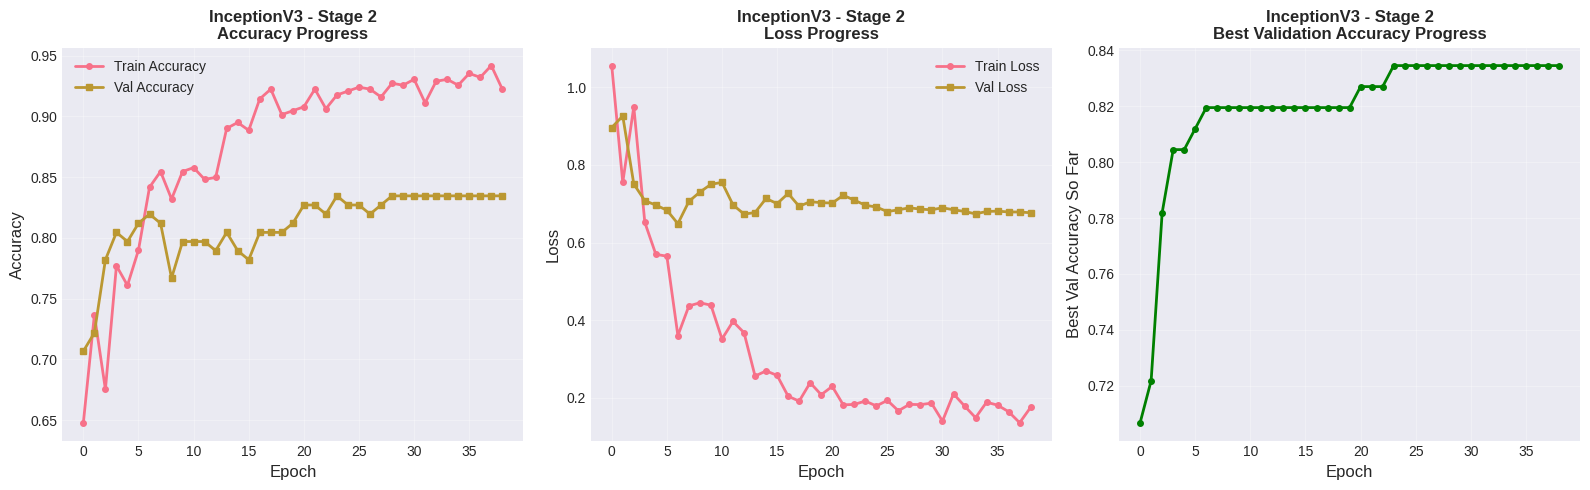


InceptionV3 - TEST RESULTS
Test Loss: 0.7353
Test Accuracy: 82.71%
Weighted F1-Score: 82.58%
Macro F1-Score: 75.36%

Classification Report:
                   precision    recall  f1-score   support

        Bird-drop       0.83      0.71      0.77        28
            Clean       0.87      0.93      0.90        29
            Dusty       0.79      0.93      0.85        28
Electrical-damage       0.91      0.62      0.74        16
              New       0.25      0.33      0.29         3
  Physical-Damage       0.75      0.82      0.78        11
     Snow-Covered       0.94      0.94      0.94        18

         accuracy                           0.83       133
        macro avg       0.76      0.76      0.75       133
     weighted avg       0.84      0.83      0.83       133



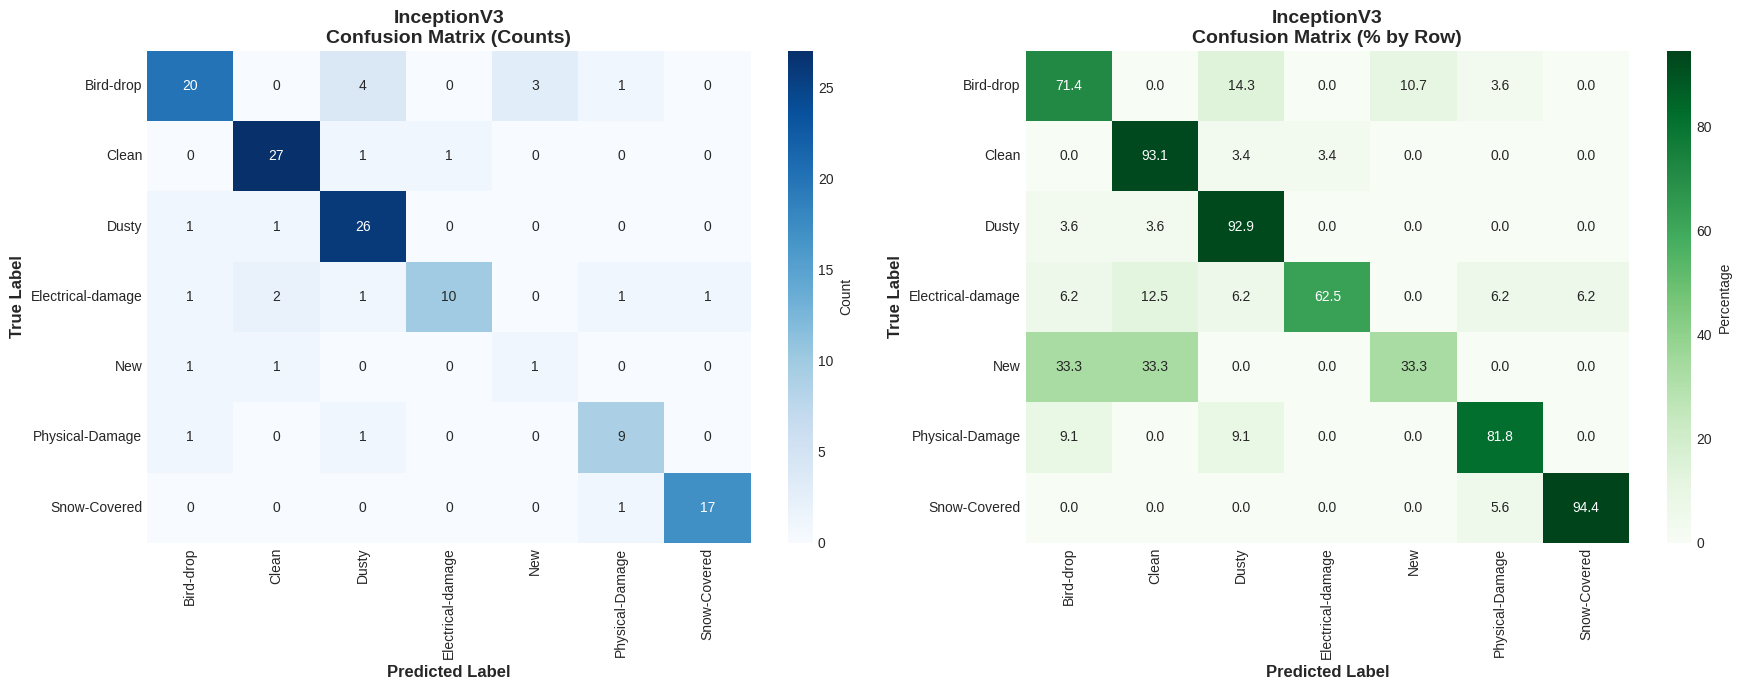

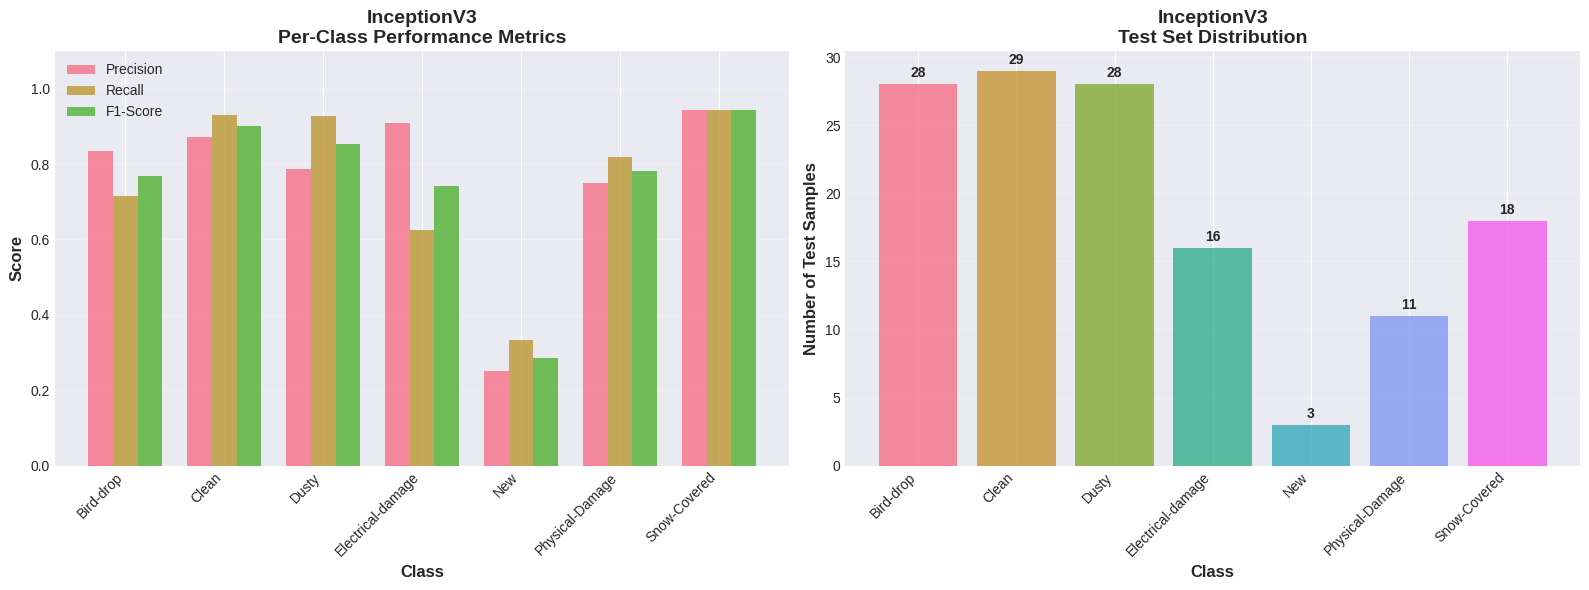

In [12]:
# STAGE 1
print("\n--- Stage 1: Training Top Layers ---")
model_inception.compile(optimizer=Adam(learning_rate=INITIAL_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_inception_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('inception_stage1.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_inception_s1 = model_inception.fit(
    train_gen_inception, epochs=EPOCHS_STAGE1, validation_data=val_gen_inception,
    class_weight=class_weight_dict, callbacks=callbacks_inception_s1, verbose=1
)

plot_training_history(history_inception_s1, "Stage 1", "InceptionV3")

# STAGE 2
print("\n--- Stage 2: Fine-Tuning ---")
model_inception.load_weights('inception_stage1.h5')

for layer in base_inception.layers[249:]:
    layer.trainable = True

model_inception.compile(optimizer=Adam(learning_rate=FINETUNE_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_inception_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('inception_best.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_inception_s2 = model_inception.fit(
    train_gen_inception, epochs=EPOCHS_STAGE2, validation_data=val_gen_inception,
    class_weight=class_weight_dict, callbacks=callbacks_inception_s2, verbose=1
)

plot_training_history(history_inception_s2, "Stage 2", "InceptionV3")

model_inception.load_weights('inception_best.h5')
acc_inception, f1_inception = evaluate_and_report(model_inception, test_gen_inception, "InceptionV3", sorted_labels)
results_dict['InceptionV3'] = {'accuracy': acc_inception, 'f1_weighted': f1_inception}


In [13]:
# ==============================================================================
# MODEL 5: MobileNetV2 (Lightweight and Fast)
# ==============================================================================

print("\n" + "="*70)
print("MODEL 5: MobileNetV2 - TWO STAGE TRAINING")
print("="*70)

from tensorflow.keras.applications import MobileNetV2

base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))
for layer in base_mobilenet.layers:
    layer.trainable = False

x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions_mobilenet = Dense(NUM_CLASSES, activation='softmax')(x)

model_mobilenet = Model(inputs=base_mobilenet.input, outputs=predictions_mobilenet)


MODEL 5: MobileNetV2 - TWO STAGE TRAINING
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



--- Stage 1: Training Top Layers ---
Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.3129 - loss: 2.3168

39/39 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.3140 - loss: 2.3090 - val_accuracy: 0.6015 - val_loss: 1.1213 - learning_rate: 0.0010
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step - accuracy: 0.4998 - loss: 1.4563 - val_accuracy: 0.5789 - val_loss: 1.1617 - learning_rate: 0.0010
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 460ms/step - accuracy: 0.5849 - loss: 1.1954 - val_accuracy: 0.5865 - val_loss: 1.0617 - learning_rate: 0.0010
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.5601 - loss: 1.3178

39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 554ms/step - accuracy: 0.5603 - loss: 1.3153 - val_accuracy: 0.6316 - val_loss: 1.1339 - learning_rate: 0.0010
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 460ms/step - accuracy: 0.5738 - loss: 1.1096 - val_accuracy: 0.6241 - val_loss: 1.1614 - learning_rate: 0.0010
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.5872 - loss: 1.1914
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step - accuracy: 0.5868 - loss: 1.1921 - val_accuracy: 0.6090 - val_loss: 1.1552 - learning_rate: 0.0010
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.6284 - loss: 1.0074

39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 474ms/step - accuracy: 0.6282 - loss: 1.0064 - val_accuracy: 0.6917 - val_loss: 0.9421 - learning_rate: 5.0000e-04
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.6803 - loss: 0.8248

39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 485ms/step - accuracy: 0.6797 - loss: 0.8274 - val_accuracy: 0.7068 - val_loss: 0.9966 - learning_rate: 5.0000e-04
Epoch 9/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 472ms/step - accuracy: 0.6711 - loss: 0.8552 - val_accuracy: 0.6917 - val_loss: 0.9783 - learning_rate: 5.0000e-04
Epoch 10/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.6955 - loss: 0.7157
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 461ms/step - accuracy: 0.6951 - loss: 0.7185 - val_accuracy: 0.6466 - val_loss: 0.9993 - learning_rate: 5.0000e-04
Epoch 11/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 471ms/step - accuracy: 0.6655 - loss: 0.8197 - val_accuracy: 0.6767 - val_loss: 1.0413 - learning_rate: 2.5000e-04
Epoch 12/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 461ms/step - accuracy: 0.7129 - loss: 0.7867 - val_accuracy: 0.6767 - val_loss: 1.0776 - learning_rate: 2.5000e-04
Epoch 13/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6981

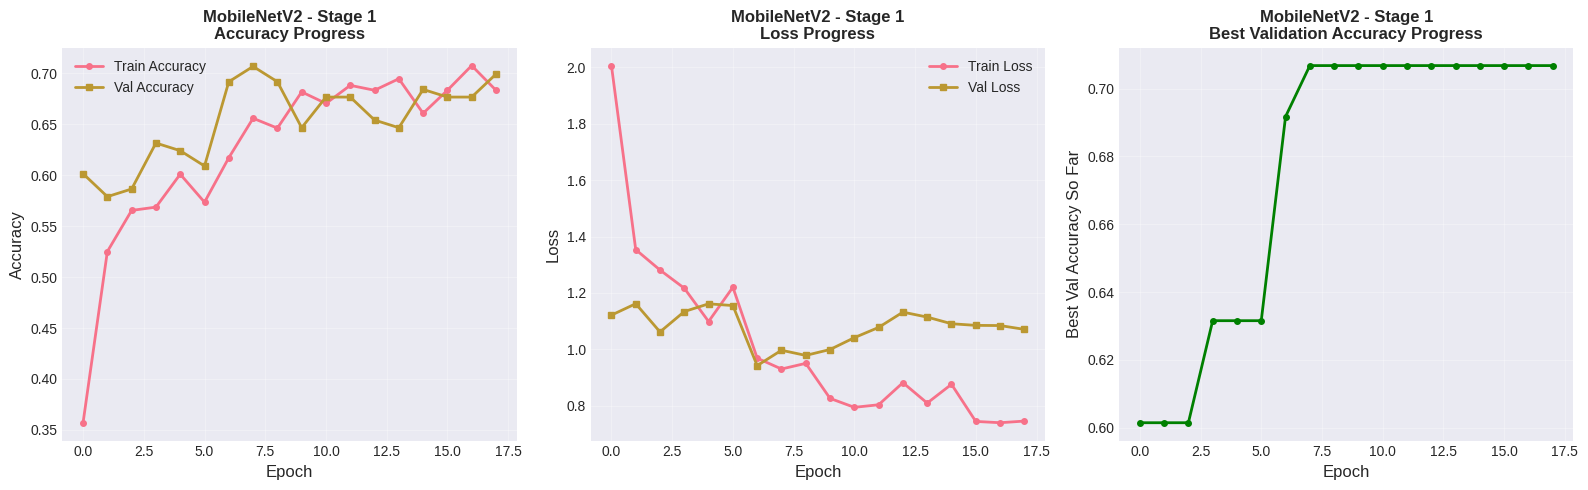

In [14]:
# STAGE 1
print("\n--- Stage 1: Training Top Layers ---")
model_mobilenet.compile(optimizer=Adam(learning_rate=INITIAL_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_mobilenet_s1 = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('mobilenet_stage1.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_mobilenet_s1 = model_mobilenet.fit(
    train_generator, epochs=EPOCHS_STAGE1, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=callbacks_mobilenet_s1, verbose=1
)

plot_training_history(history_mobilenet_s1, "Stage 1", "MobileNetV2")


--- Stage 2: Fine-Tuning ---
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.5144 - loss: 1.3792

39/39 ━━━━━━━━━━━━━━━━━━━━ 54s 911ms/step - accuracy: 0.5144 - loss: 1.3776 - val_accuracy: 0.6241 - val_loss: 1.2252 - learning_rate: 1.0000e-04
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 458ms/step - accuracy: 0.6114 - loss: 1.0331 - val_accuracy: 0.5940 - val_loss: 1.8616 - learning_rate: 1.0000e-04
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 484ms/step - accuracy: 0.6033 - loss: 0.9159 - val_accuracy: 0.5714 - val_loss: 1.9633 - learning_rate: 1.0000e-04
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 467ms/step - accuracy: 0.6539 - loss: 0.8056 - val_accuracy: 0.5489 - val_loss: 2.4059 - learning_rate: 1.0000e-04
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 494ms/step - accuracy: 0.6705 - loss: 0.7796 - val_accuracy: 0.5714 - val_loss: 2.0708 - learning_rate: 1.0000e-04
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.6528 - loss: 0.8321
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 461ms/step - accuracy: 0.6526 - l

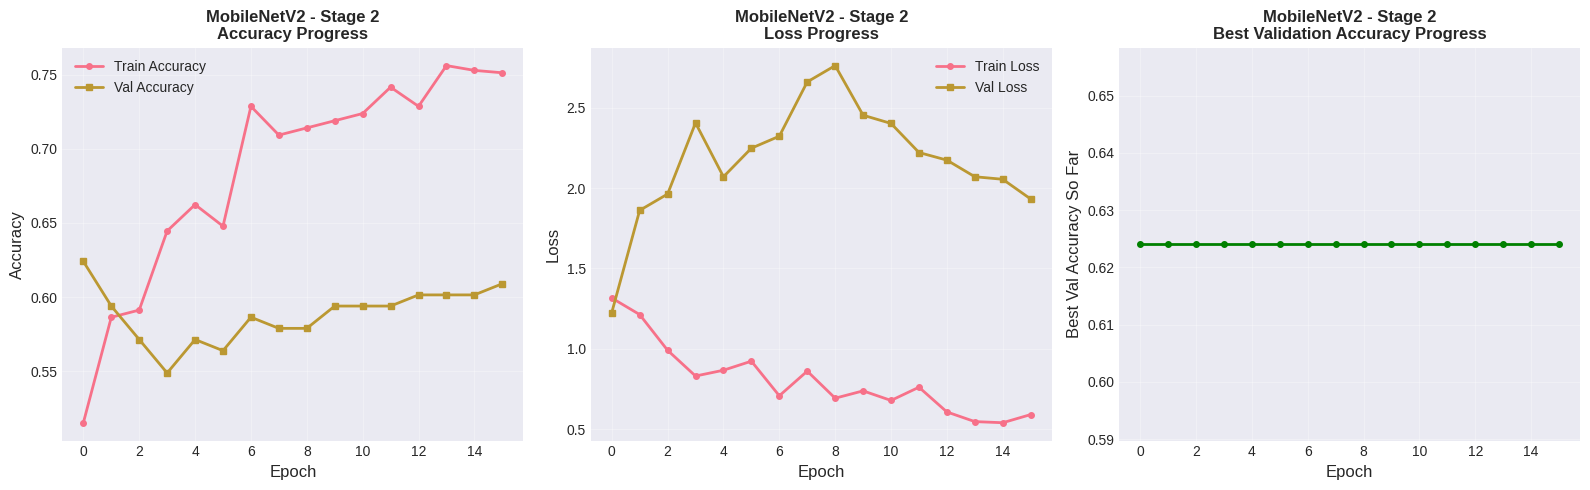


MobileNetV2 - TEST RESULTS
Test Loss: 1.3236
Test Accuracy: 57.89%
Weighted F1-Score: 57.44%
Macro F1-Score: 50.72%

Classification Report:
                   precision    recall  f1-score   support

        Bird-drop       0.67      0.43      0.52        28
            Clean       0.45      0.90      0.60        29
            Dusty       0.67      0.43      0.52        28
Electrical-damage       0.93      0.81      0.87        16
              New       0.00      0.00      0.00         3
  Physical-Damage       0.36      0.45      0.40        11
     Snow-Covered       0.90      0.50      0.64        18

         accuracy                           0.58       133
        macro avg       0.57      0.50      0.51       133
     weighted avg       0.64      0.58      0.57       133



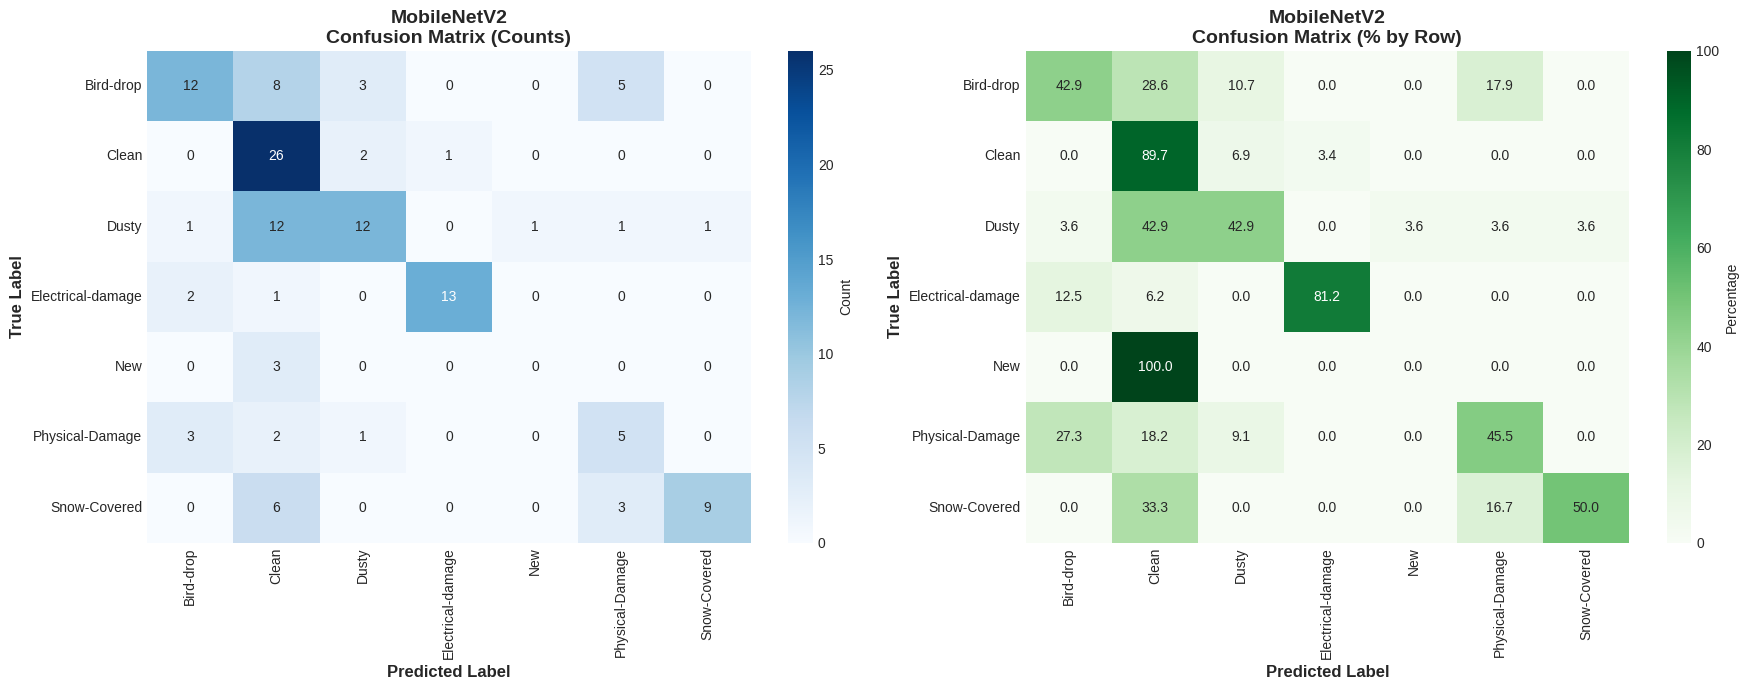

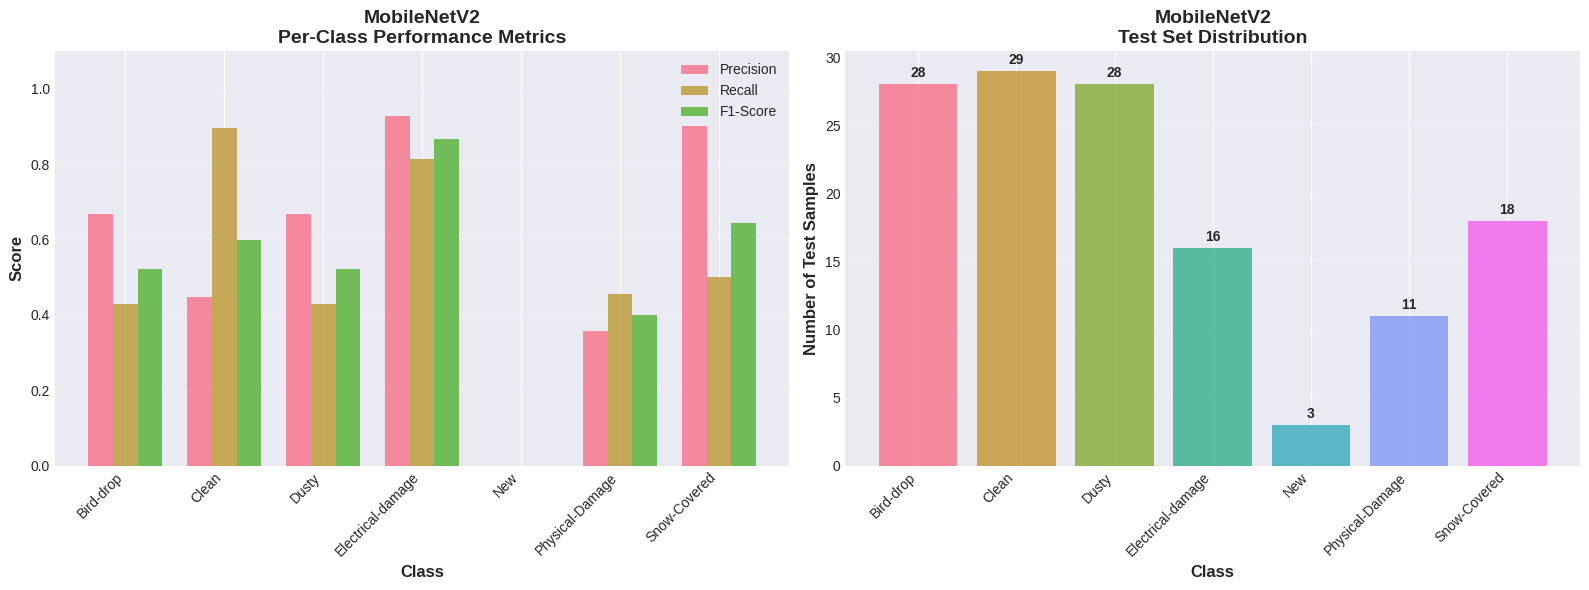

In [15]:
# STAGE 2
print("\n--- Stage 2: Fine-Tuning ---")
model_mobilenet.load_weights('mobilenet_stage1.h5')

# Unfreeze last 30 layers
for layer in base_mobilenet.layers[-30:]:
    layer.trainable = True

model_mobilenet.compile(optimizer=Adam(learning_rate=FINETUNE_LR), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_mobilenet_s2 = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint('mobilenet_best.h5', monitor='val_accuracy', save_best_only=True, mode='max')
]

history_mobilenet_s2 = model_mobilenet.fit(
    train_generator, epochs=EPOCHS_STAGE2, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=callbacks_mobilenet_s2, verbose=1
)

plot_training_history(history_mobilenet_s2, "Stage 2", "MobileNetV2")

model_mobilenet.load_weights('mobilenet_best.h5')
acc_mobilenet, f1_mobilenet = evaluate_and_report(model_mobilenet, test_generator, "MobileNetV2", sorted_labels)
results_dict['MobileNetV2'] = {'accuracy': acc_mobilenet, 'f1_weighted': f1_mobilenet}



FINAL MODEL COMPARISON - ALL 5 MODELS


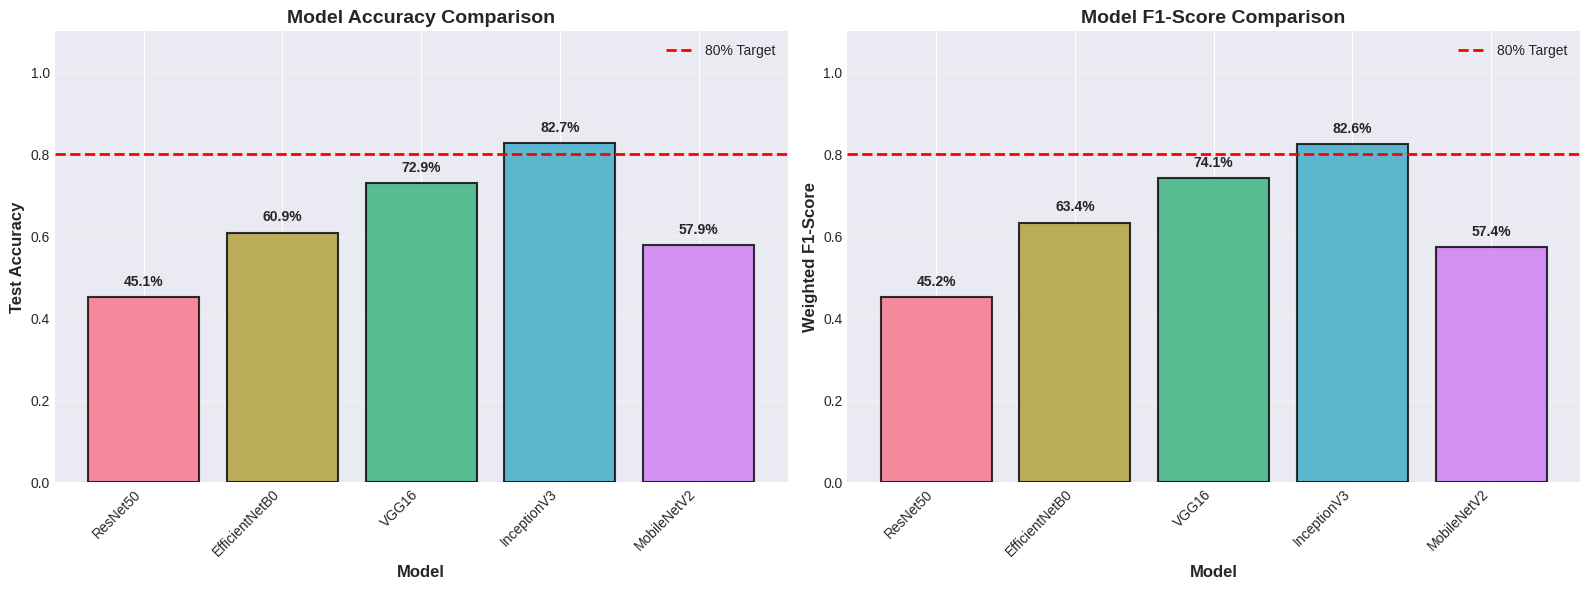


         Model Test Accuracy Weighted F1-Score
      ResNet50        45.11%            45.23%
EfficientNetB0        60.90%            63.36%
         VGG16        72.93%            74.12%
   InceptionV3        82.71%            82.58%
   MobileNetV2        57.89%            57.44%

TRAINING COMPLETE - ALL 5 MODELS!


In [16]:
# ==============================================================================
# FINAL COMPARISON
# ==============================================================================

print("\n" + "="*70)
print("FINAL MODEL COMPARISON - ALL 5 MODELS")
print("="*70)

plot_model_comparison(results_dict)

comparison_df = pd.DataFrame({
    'Model': list(results_dict.keys()),
    'Test Accuracy': [results_dict[m]['accuracy'] for m in results_dict.keys()],
    'Weighted F1-Score': [results_dict[m]['f1_weighted'] for m in results_dict.keys()]
})

comparison_df['Test Accuracy'] = (comparison_df['Test Accuracy'] * 100).map('{:.2f}%'.format)
comparison_df['Weighted F1-Score'] = (comparison_df['Weighted F1-Score'] * 100).map('{:.2f}%'.format)

print("\n" + comparison_df.to_string(index=False))
print("\n" + "="*70)
print("TRAINING COMPLETE - ALL 5 MODELS!")
print("="*70)